### Helpers

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from typing import Callable
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic

# --- CONFIGURATION ---

# Column mappings (Key = logical name, Value = CSV column name)
COLS = {
    'time': 'time',
    'modus': ['modus_val', 'modus'], # List allows fallback
    'fan': 'VD_n2',
    'mass': 'MSS_rMassenstrom',
    'p_in': 'VD_p_out',
    'h_in': ['VD_h_in_korr', 'VD_isenthalp_h_in'],
    'temp_kk': 'TempKK',
    'rh_kk': ['KK_rlFeuchteKK', 'rlFeuchteKK']
}

# Ensure project root is in path
project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# ===============================================================================
# DATA STRUCTURES
# ===============================================================================

@dataclass
class ExperimentInputs:
    id: str
    duration: float
    averages: tuple[float, float]  # (Temp, Humidity)
    trends: dict[str, Callable[[float], float]]

    def __str__(self):
        """Generates a clean dashboard-style text report."""
        return (
            f"  Duration      : {self.duration:.2f} min\n"
        )

# ===============================================================================
# ANALYSIS LOGIC
# ===============================================================================

def get_col(df: pd.DataFrame, keys):
    """Safe retrieval of columns handling fallbacks (e.g. modus vs modus_val)."""
    if isinstance(keys, str): keys = [keys]
    for k in keys:
        if k in df.columns: return df[k]
    raise KeyError(f"None of {keys} found in DataFrame.")

def polynomial_fit(x, y, degree=1):
    """
    Fits a polynomial of order `degree`.
    Returns a callable function f(t).
    """
    if len(x) == 0: return lambda t: 0.0
    
    # 1. Calculate coefficients
    coeffs = np.polyfit(x, y, degree)
    
    # 2. Create a function from those coefficients
    poly_func = np.poly1d(coeffs)
    
    return poly_func

def rolling_trend(x, y, **kwargs):
    """
    Calculates a rolling mean and returns a callable interpolator function.
    
    Args:
        x: Time array (independent variable) - required for interpolation
        y: Data array (dependent variable)
        kwargs: 'window' (int) for rolling window size.
    
    Returns:
        function f(t) -> interpolated value
    """
    if len(x) == 0: return lambda t: 0.0
    
    # 1. Calculate the rolling mean (User's snippet)
    window = kwargs.get('window', 2000)
    y_rolled = pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().to_numpy()
    
    # 2. Wrap in an interpolator
    # This makes the result compatible with 'ExperimentInputs' which expects a Callable.
    # When you call trends['mass'](t), it interpolates between the rolling mean points.
    def trend_func(t):
        return np.interp(t, x, y_rolled)
        
    return trend_func

def hard_step_avg(x, y, interval_minutes=3.0):
    """
    1. Breaks time into strict chunks (0-3, 3-6, 6-9...).
    2. Calculates the MEAN of the data inside that chunk.
    3. Locks that value flat for the entire duration (Zero-Order Hold).
    """
    if len(x) == 0: return lambda t: 0.0

    # 1. Define the Bin Edges (0, 3, 6, 9... up to the end)
    t_max = np.max(x)
    # Create bins ensuring we cover the full range
    bins = np.arange(0, t_max + interval_minutes, interval_minutes)
    
    # 2. Compute Mean for each Bin
    # This gives us ONE value per interval.
    bin_means, bin_edges, _ = binned_statistic(x, y, statistic='mean', bins=bins)
    
    # 3. Handle Empty Bins 
    # (If a 3-min gap has no data, hold the previous value so it doesn't crash)
    bin_means = pd.Series(bin_means).ffill().bfill().to_numpy()

    # 4. Create the "Zero-Order Hold" Function
    # 'bin_edges[:-1]' are the start times: [0, 3, 6...]
    # kind='zero' means: "For any time t between 0 and 3, return the value at 0."
    f = interp1d(
        bin_edges[:-1], 
        bin_means, 
        kind='zero', 
        fill_value="extrapolate", 
        bounds_error=False
    )
    
    return f

def analyze_combined_experiments(exp_ids: list[int], path: Path, cutoff_pct: float, time_step: float) -> ExperimentInputs:
    """
    Aggregates data from multiple experiments and creates a combined regression trend.
    """
    
    # Data containers for concatenation
    combined_data = {
        'time': [], 'time_stable': [],
        'fan': [], 'mass': [], 'p': [], 'h': [], 'temp': [], 'rh': []
    }
    
    durations = []
    t_avgs = []
    rh_avgs = []

    print(f"--- Aggregating Data for Experiments: {exp_ids} ---")

    for exp_id in exp_ids:
        # --- Load Data (Same logic as before) ---
        try:
            df = pd.read_csv(path / f"{exp_id}_data.csv", sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
            df_kk = pd.read_csv(path / f"{exp_id}_data_KK.csv", sep=';', decimal='.', low_memory=False)
        except FileNotFoundError:
            print(f"Warning: Skipping {exp_id}, file not found.")
            continue

        # Filter by Mode
        mask_mode = get_col(df, COLS['modus']) == 1
        valid_idx = df.index[mask_mode].intersection(df_kk.index)
        df = df.loc[valid_idx]
        df_kk = df_kk.loc[valid_idx]

        if df.empty:
            print(f"Warning: {exp_id} has no valid mode data.")
            continue

        # Time Calculations
        t_raw = get_col(df, COLS['time'])
        x_time = (t_raw - t_raw.iloc[0]).values / 60.0 # Minutes
        
        total_dur = np.max(x_time)
        durations.append(total_dur)
        mask_stable = x_time >= (total_dur * cutoff_pct)

        # Extract Series
        combined_data['time'].append(x_time)
        combined_data['time_stable'].append(x_time[mask_stable])
        
        combined_data['fan'].append(get_col(df, COLS['fan']) * 60.0)
        combined_data['mass'].append((get_col(df, COLS['mass']) / 1000.0)[mask_stable])
        combined_data['p'].append(get_col(df, COLS['p_in'])[mask_stable])
        combined_data['h'].append(get_col(df, COLS['h_in'])[mask_stable])
        combined_data['temp'].append(get_col(df_kk, COLS['temp_kk'])[mask_stable])
        combined_data['rh'].append(get_col(df_kk, COLS['rh_kk'])[mask_stable])

        # Averages for meta-data
        t_avgs.append(get_col(df_kk, COLS['temp_kk'])[mask_stable].mean())
        rh_avgs.append(get_col(df_kk, COLS['rh_kk'])[mask_stable].mean())

    # --- Concatenate All Data ---
    # We flatten the lists of arrays into single 1D arrays
    X_all = np.concatenate(combined_data['time'])
    X_stable = np.concatenate(combined_data['time_stable'])
    
    Y_fan = np.concatenate(combined_data['fan'])
    Y_mass = np.concatenate(combined_data['mass'])
    Y_p = np.concatenate(combined_data['p'])
    Y_h = np.concatenate(combined_data['h'])
    Y_temp = np.concatenate(combined_data['temp'])
    Y_rh = np.concatenate(combined_data['rh'])

    # --- Generate Combined Trends ---
    # Note: We fit the polynomial through the cloud of ALL points from ALL experiments
    trends = {
        'fan':  hard_step_avg(X_all, Y_fan, interval_minutes=time_step/60.0),
        'mass': polynomial_fit(X_stable, Y_mass, degree=5),
        'p':    polynomial_fit(X_stable, Y_p, degree=5),
        'h':    polynomial_fit(X_stable, Y_h, degree=5),
        'temp': polynomial_fit(X_stable, Y_temp, degree=0),
        'rh':   polynomial_fit(X_stable, Y_rh, degree=0),
    }

    # Use average duration or max duration? Usually average is safer for "mean" behavior, 
    # but max ensures we cover the longest experiment. 
    avg_duration = np.mean(durations) if durations else 0.0

    return ExperimentInputs(
        id=f"Combined_{len(exp_ids)}_Exps", 
        duration=avg_duration, 
        averages=(np.mean(t_avgs), np.mean(rh_avgs)), 
        trends=trends
    )

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import os
import CoolProp.CoolProp as CP

def plot_input_comparison(states_history, inputs_history, params, experiment_ids, path_exp, cutoff_pct=0.10, save_fig=False):
    """
    Plots the Top 6 Input Parameters.
    Comparing up to 5 Experiments (Blue Gradient) vs 1 Simulation (Black).
    
    FEATURE: Y-Axis scaling is calculated based ONLY on the stable region 
             (excluding cutoff areas), but X-Axis shows full duration.
    """

    # --- CONFIGURATION: COLORS ---
    BLUE_GRADIENT = [
        '#89CFF0',  # Baby Blue
        '#4682B4',  # Steel Blue
        '#0047AB',  # Cobalt
        '#000080',  # Navy
        '#04043A'   # Midnight Blue (Almost Black)
    ]
    
    if len(experiment_ids) > 5:
        raise ValueError(f"Too many experiments ({len(experiment_ids)}). Maximum allowed is 5.")

    # =========================================================================
    # 1. PREPARE DATA CONTAINERS
    # =========================================================================
    steps = len(states_history)
    t_sim = np.array([i * params.time_step / 60.0 for i in range(steps)])
    t_total = t_sim[-1]
    
    # Define stable window indices for Simulation
    # We use these to collect data for auto-scaling later
    t_cut_start = t_total * cutoff_pct
    t_cut_end = t_total * (1.0 - cutoff_pct)
    
    # Container to hold all valid data points for scaling (per axis key)
    scaling_data = {
        'n_fan': [], 'T_in': [], 'rh_in': [], 
        'm_ref': [], 'p_ref_in': [], 'h_ref_in': []
    }

    # --- EXTRACT SIMULATION DATA ---
    sim = {k: [] for k in scaling_data.keys()}
    num_layers = len(states_history[0])
    
    for t in range(steps):
        # Air Side
        inp_air = inputs_history[t][0].air
        sim['T_in'].append(inp_air.T_in - 273.15)
        sim['n_fan'].append(inp_air.fan_speed_rpm)
        
        try:
            rh_calc = CP.HAPropsSI('R', 'T', inp_air.T_in, 'P', inp_air.p_in, 'W', inp_air.W_in)
            sim['rh_in'].append(rh_calc * 100.0)
        except:
            sim['rh_in'].append(0.0)

        # Ref Side
        ref_in_idx = num_layers - 1
        inp_ref = inputs_history[t][ref_in_idx].refrigerant
        reg_amount = REGISTER_AMOUNT if hasattr(params, 'register_amount') else 8.0
        
        sim['m_ref'].append(inp_ref.m_dot * reg_amount) 
        sim['p_ref_in'].append(inp_ref.p_eva / 1e5)
        sim['h_ref_in'].append(inp_ref.h_in / 1e3)

    # Convert to arrays and collect STABLE data for scaling
    mask_sim_stable = (t_sim >= t_cut_start) & (t_sim <= t_cut_end)
    for k in sim:
        sim[k] = np.array(sim[k])
        # Add only the stable part to our scaling calculator
        if np.any(mask_sim_stable):
            scaling_data[k].extend(sim[k][mask_sim_stable])

    # =========================================================================
    # 2. SETUP PLOTTING GRID
    # =========================================================================
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f"Input Comparison: {len(experiment_ids)} Experiments vs Simulation", fontsize=18, fontweight='bold', y=0.96)

    gs = gridspec.GridSpec(2, 3, figure=fig, wspace=0.25, hspace=0.3, 
                           top=0.90, bottom=0.08, left=0.05, right=0.95)

    ax_fan = fig.add_subplot(gs[0, 0])
    ax_temp = fig.add_subplot(gs[0, 1])
    ax_rh = fig.add_subplot(gs[0, 2])
    ax_mass = fig.add_subplot(gs[1, 0])
    ax_h = fig.add_subplot(gs[1, 1])
    ax_p = fig.add_subplot(gs[1, 2])

    axes_map = [
        (ax_fan,  'n_fan',      'Fan Speed',          '[rpm]'),
        (ax_temp, 'T_in',       'Air Inlet Temp',     '[°C]'),
        (ax_rh,   'rh_in',      'Air Inlet RH',       '[%]'),
        (ax_mass, 'm_ref',      'Ref. Mass Flow',     '[kg/s]'),
        (ax_h,    'h_ref_in',   'Ref. Inlet Enthalpy','[kJ/kg]'),
        (ax_p,    'p_ref_in',   'Evap. Inlet Pressure','[bar]')
    ]

    # =========================================================================
    # 3. LOAD AND PLOT EXPERIMENTS
    # =========================================================================
    print(f"--- Visualizing Inputs for {len(experiment_ids)} Experiments ---")

    for idx, exp_id in enumerate(experiment_ids):
        try:
            file_data = os.path.join(path_exp, f"{exp_id}_data.csv")
            file_kk = os.path.join(path_exp, f"{exp_id}_data_KK.csv")

            if not (os.path.exists(file_data) and os.path.exists(file_kk)):
                continue

            # Load
            df = pd.read_csv(file_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
            df_kk = pd.read_csv(file_kk, sep=';', decimal='.', low_memory=False)

            # Filter Mode
            col_modus = 'modus_val' if 'modus_val' in df.columns else 'modus'
            if col_modus in df.columns:
                mask = df[col_modus] == 1
                valid_idx = df.index[mask].intersection(df_kk.index)
                df = df.loc[valid_idx]
                df_kk = df_kk.loc[valid_idx]

            if df.empty: continue

            # Time
            t_raw = df['time']
            t_exp = (t_raw - t_raw.iloc[0]).values / 60.0

            # Data Extraction
            exp_data = {}
            exp_data['n_fan'] = df['VD_n2'].values * 60.0
            exp_data['T_in'] = df_kk['TempKK'].values
            
            col_rh = 'KK_rlFeuchteKK' if 'KK_rlFeuchteKK' in df_kk.columns else 'rlFeuchteKK'
            exp_data['rh_in'] = df_kk[col_rh].values
            
            exp_data['m_ref'] = df['MSS_rMassenstrom'].values / 1000.0
            exp_data['p_ref_in'] = df['VD_p_out'].values
            
            col_h = 'VD_h_in_korr' if 'VD_h_in_korr' in df.columns else 'VD_isenthalp_h_in'
            exp_data['h_ref_in'] = df[col_h].values

            # Plot & Collect Stable Data
            c_exp = BLUE_GRADIENT[idx]
            
            # Mask for stable region of THIS experiment
            mask_exp_stable = (t_exp >= t_cut_start) & (t_exp <= t_cut_end)

            for ax, key, _, _ in axes_map:
                if key in exp_data:
                    # Plot FULL data
                    ax.plot(t_exp, exp_data[key], color=c_exp, lw=1.5, alpha=0.6, 
                            label=f"Exp {exp_id}" if key=='n_fan' else "")
                    
                    # Collect ONLY STABLE data for scaling
                    if np.any(mask_exp_stable):
                        scaling_data[key].extend(exp_data[key][mask_exp_stable])

        except Exception as e:
            print(f"Error processing Exp {exp_id}: {e}")

    # =========================================================================
    # 4. PLOT SIMULATION, FORMATTING & SMART SCALING
    # =========================================================================
    
    for ax, key, title, unit in axes_map:
        # Plot Simulation (Black)
        # ax.plot(t_sim, sim[key], color='black', lw=2.5, linestyle='-', label='SIM', zorder=10)
        
        # Formatting
        ax.set_title(title, fontsize=12, fontweight='bold', color='#333333')
        ax.set_ylabel(unit, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Grey Cutoff Areas
        ax.axvspan(0, t_cut_start, color='gray', alpha=0.15, lw=0)
        ax.axvline(t_cut_start, color='gray', linestyle=':', linewidth=1)
        ax.axvspan(t_cut_end, t_total, color='gray', alpha=0.15, lw=0)
        ax.axvline(t_cut_end, color='gray', linestyle=':', linewidth=1)
        
        # --- SMART Y-LIMIT SCALING ---
        # Calculate limits based ONLY on data within the stable region
        data_points = np.array(scaling_data[key])
        
        if len(data_points) > 0:
            y_min = np.min(data_points)
            y_max = np.max(data_points)
            
            # Calculate Range
            y_range = y_max - y_min
            
            # Handle edge case of flat line (range = 0)
            if y_range == 0:
                y_range = max(abs(y_max) * 0.1, 1.0) # Default buffer
            
            # Apply 30% Buffer (0.3)
            buffer = y_range * 0.30
            
            new_ylim = (y_min - buffer, y_max + buffer)
            ax.set_ylim(new_ylim)
            
            # Ensure X-axis shows everything (Start to End)
            ax.set_xlim(0, t_total)

    # Legend on first plot
    handles, labels = ax_fan.get_legend_handles_labels()
    if handles:
        ax_fan.legend(handles, labels, fontsize=9, loc='best', framealpha=0.9)

    if save_fig:
        out_name = f"MultiExp_Inputs_{len(experiment_ids)}_vs_Sim.png"
        out_path = os.path.join(path_exp, "graphics", "combined", out_name)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=300)
        print(f"Saved figure to {out_path}")
        plt.close()
    else:
        plt.show()

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import os
import CoolProp.CoolProp as CP

def plot_all_comparison_multi(states_history, inputs_history, params, experiment_ids, path_exp, cutoff_pct=0.10, save_fig=False, group_name=None):
    """
    Master Dashboard: Comparison of N Experiments vs 1 Simulation.
    
    TOP HALF (Inputs): 
      - 6 Parameters (Fan, T_in, RH, m_dot, h_in, p_in)
      - Blue Gradient for Experiments.
      - Smart Scaling (zooms Y-axis to stable region).

    BOTTOM HALF (Outputs): 
      - 4 Parameters (dP, h_out, Q, m_frost)
      - Red Gradient for Experiments.
      - Includes Deviation Plots underneath each output.
      - Legend shows Average Error per Experiment.
    """

    # =========================================================================
    # 0. CONFIGURATION & COLORS
    # =========================================================================
    
    # Blue Gradient (Inputs)
    BLUE_GRADIENT = ['#89CFF0', '#4682B4', '#0047AB', '#000080', '#04043A']
    
    # Red Gradient (Outputs)
    RED_GRADIENT  = ['#FFB3B3', '#FF8080', '#FF4D4D', '#E60000', '#8B0000']
    
    c_sim = 'black'
    c_sim_ref = '#0C00A4' # For dashed reference lines (e.g. Inlet Enthalpy on Outlet plot)

    if len(experiment_ids) > 5:
        raise ValueError(f"Too many experiments ({len(experiment_ids)}). Maximum allowed is 5.")

    # =========================================================================
    # 1. DATA PREPARATION
    # =========================================================================
    steps = len(states_history)
    t_sim = np.array([i * params.time_step / 60.0 for i in range(steps)])
    t_total = t_sim[-1]

    # Cutoff timestamps
    t_cut_start = t_total * cutoff_pct
    t_cut_end = t_total * (1.0 - cutoff_pct)
    mask_sim_stable = (t_sim >= t_cut_start) & (t_sim <= t_cut_end)

    # --- SIMULATION DATA ---
    # We collect everything into a single dict for easy access
    sim_data = {
        # Inputs
        'n_fan': [], 'T_in': [], 'rh_in': [], 
        'm_ref': [], 'p_ref_in': [], 'h_ref_in': [],
        # Outputs
        'dp': [], 'h_ref_out': [], 'Q': [], 'm_frost': []
    }

    num_layers = len(states_history[0])
    reg_amount = REGISTER_AMOUNT if hasattr(params, 'register_amount') else 8.0

    for t in range(steps):
        # -- Inputs --
        inp_air = inputs_history[t][0].air
        sim_data['T_in'].append(inp_air.T_in - 273.15)
        sim_data['n_fan'].append(inp_air.fan_speed_rpm)
        
        try:
            rh = CP.HAPropsSI('R', 'T', inp_air.T_in, 'P', inp_air.p_in, 'W', inp_air.W_in)
            sim_data['rh_in'].append(rh * 100.0)
        except:
            sim_data['rh_in'].append(0.0)

        ref_in_idx = num_layers - 1
        inp_ref = inputs_history[t][ref_in_idx].refrigerant
        sim_data['m_ref'].append(inp_ref.m_dot * reg_amount)
        sim_data['p_ref_in'].append(inp_ref.p_eva / 1e5)
        sim_data['h_ref_in'].append(inp_ref.h_in / 1e3)

        # -- Outputs --
        dp_total = 0; q_total = 0; mass_frost_total = 0
        sim_data['h_ref_out'].append(states_history[t][0].refrigerant.h_out / 1e3)

        for k in range(num_layers):
            s = states_history[t][k]
            dp_total += s.air.pressure_drop
            q_total += s.hmt.Q_dot_total
            mass_frost_total += (s.frost.mass * 1000.0 * reg_amount)
        
        sim_data['dp'].append(dp_total)
        sim_data['Q'].append(q_total * reg_amount)
        sim_data['m_frost'].append(mass_frost_total)

    # Convert to Numpy
    for k in sim_data:
        sim_data[k] = np.array(sim_data[k])

    # --- EXPERIMENT DATA ---
    experiments = []
    
    # Scaling Calculator: Collect ALL stable data points here to determine Y-limits
    scaling_data = {k: [] for k in sim_data.keys()}
    
    # Add Sim stable data to scaling
    for k in scaling_data:
        if np.any(mask_sim_stable):
            scaling_data[k].extend(sim_data[k][mask_sim_stable])

    print(f"--- Processing {len(experiment_ids)} Experiments ---")
    
    for exp_id in experiment_ids:
        entry = {'id': exp_id, 'avail': False, 'time': None, 'data': {}}
        try:
            f_data = os.path.join(path_exp, f"{exp_id}_data.csv")
            f_kk = os.path.join(path_exp, f"{exp_id}_data_KK.csv")

            if os.path.exists(f_data) and os.path.exists(f_kk):
                df = pd.read_csv(f_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
                df_kk = pd.read_csv(f_kk, sep=';', decimal='.', low_memory=False)

                col_modus = 'modus_val' if 'modus_val' in df.columns else 'modus'
                if col_modus in df.columns:
                    mask = df[col_modus] == 1
                    valid = df.index[mask].intersection(df_kk.index)
                    df = df.loc[valid]
                    df_kk = df_kk.loc[valid]

                if not df.empty:
                    # Time
                    t_raw = df['time']
                    t_exp = (t_raw - t_raw.iloc[0]).values / 60.0
                    entry['time'] = t_exp
                    
                    # -- Extract All Variables --
                    d = {}
                    
                    # Inputs
                    d['n_fan'] = df['VD_n2'].values * 60.0
                    d['T_in'] = df_kk['TempKK'].values
                    col_rh = 'KK_rlFeuchteKK' if 'KK_rlFeuchteKK' in df_kk.columns else 'rlFeuchteKK'
                    d['rh_in'] = df_kk[col_rh].values
                    d['m_ref'] = df['MSS_rMassenstrom'].values / 1000.0
                    d['p_ref_in'] = df['VD_p_out'].values
                    col_h = 'VD_h_in_korr' if 'VD_h_in_korr' in df.columns else 'VD_isenthalp_h_in'
                    d['h_ref_in'] = df[col_h].values

                    # Outputs
                    d['h_ref_out'] = df['VD_h_out'].values
                    d['dp'] = df['Delta_P_VD'].values if 'Delta_P_VD' in df.columns else np.zeros(len(df))
                    
                    # Q calculation
                    q_kw = d['m_ref'] * (d['h_ref_out'] - d['h_ref_in'])
                    d['Q'] = q_kw * 1000.0
                    
                    # Frost Mass
                    col_mass = 'WAAGEN_Waage1_Masse_smooth' if 'WAAGEN_Waage1_Masse_smooth' in df.columns else 'WAAGEN_Waage2_Masse'
                    if col_mass in df.columns:
                        m_raw = df[col_mass].values
                        d['m_frost'] = (m_raw - np.min(m_raw)) * 1000.0
                    else:
                        d['m_frost'] = np.zeros(len(df))

                    entry['data'] = d
                    entry['avail'] = True

                    # Collect Stable Data for Scaling
                    mask_exp_stable = (t_exp >= t_cut_start) & (t_exp <= t_cut_end)
                    for k in d:
                        if k in scaling_data and np.any(mask_exp_stable):
                            scaling_data[k].extend(d[k][mask_exp_stable])

        except Exception as e:
            print(f"Error loading {exp_id}: {e}")
        
        experiments.append(entry)

    # =========================================================================
    # 2. PLOTTING INFRASTRUCTURE
    # =========================================================================
    fig = plt.figure(figsize=(24, 13))
    # Titel dynamisch setzen
    if group_name:
        title_text = f"Unified Dashboard: {group_name}"
    else:
        title_text = f"Unified Dashboard: {len(experiment_ids)} Experiments vs Simulation"

    fig.suptitle(title_text, fontsize=20, fontweight='bold', y=0.96)

    # Top Half: Inputs 
    # Matches original: top=0.90, bottom=0.45
    gs_top = gridspec.GridSpec(2, 3, figure=fig, 
                               top=0.90, bottom=0.45, hspace=0.35, wspace=0.20)
    
    # Bottom Half: Outputs
    # Matches original: top=0.38, bottom=0.05 
    # height_ratios=[3, 1.2] ensures the value plot is 3x taller than the error plot
    gs_bot = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[3, 1.2], 
                               top=0.38, bottom=0.05, hspace=0.0, wspace=0.20)

    # Helper: Cutoff Visualization
    def add_cutoff_vis(ax, show_labels=False):
        ax.axvspan(0, t_cut_start, color='gray', alpha=0.15, lw=0)
        ax.axvline(t_cut_start, color='gray', linestyle=':', linewidth=1)
        ax.axvspan(t_cut_end, t_total, color='gray', alpha=0.15, lw=0)
        ax.axvline(t_cut_end, color='gray', linestyle=':', linewidth=1)
        if show_labels:
            ax.text(t_cut_start/2, ax.get_ylim()[1], "Start", ha='center', va='bottom', fontsize=8, color='gray', fontstyle='italic')

    # Helper: Apply Smart Scaling
    def apply_smart_scaling(ax, key):
        data_pts = np.array(scaling_data[key])
        if len(data_pts) > 0:
            y_min, y_max = np.min(data_pts), np.max(data_pts)
            
            # --- FORCE ZERO FOR FROST MASS ---
            if key == 'm_frost':
                y_min = 0.0
            
            y_range = y_max - y_min
            if y_range == 0: y_range = max(abs(y_max)*0.1, 1.0)
            
            # Apply buffer only to max if min is fixed at 0
            buffer_top = y_range * 0.10
            buffer_bot = y_range * 0.10 if key != 'm_frost' else 0.0

            bottom = y_min - buffer_bot
            top = y_max + buffer_top
            
            # Check if they are valid numbers
            if np.isfinite(bottom) and np.isfinite(top):
                ax.set_ylim(bottom, top)
            else:
                print(f"Warning: Invalid limits detected (bottom: {bottom}, top: {top}). Using default scaling.")
            
        ax.set_xlim(0, t_total)

    # =========================================================================
    # 3. PLOT INPUTS (TOP HALF)
    # =========================================================================
    input_map = [
        (0, 0, 'n_fan',      'Fan Speed',          '[rpm]'),
        (0, 1, 'T_in',       'Air Inlet Temp',     '[°C]'),
        (0, 2, 'rh_in',      'Air Inlet RH',       '[%]'),
        (1, 0, 'm_ref',      'Ref. Mass Flow',     '[kg/s]'),
        (1, 1, 'h_ref_in',   'Ref. Inlet Enthalpy','[kJ/kg]'),
        (1, 2, 'p_ref_in',   'Evap. Inlet Pressure','[bar]')
    ]

    for r, c, key, title, unit in input_map:
        ax = fig.add_subplot(gs_top[r, c])
        
        # Plot Experiments (Blue)
        for idx, exp in enumerate(experiments):
            if exp['avail'] and key in exp['data']:
                lbl = f"Exp {exp['id']}" if (r==0 and c==0) else ""
                ax.plot(exp['time'], exp['data'][key], color=BLUE_GRADIENT[idx], lw=1.5, alpha=0.6, label=lbl)
        
        # Plot Sim (Black)
        if key == 'n_fan':
             ax.plot(t_sim, sim_data[key], color=c_sim, lw=2.5, drawstyle='steps-post',label="SIM" if (r==0 and c==0) else "")
        else:
             ax.plot(t_sim, sim_data[key], color=c_sim, lw=2.5, label="SIM" if (r==0 and c==0) else "")

        # Formatting
        add_cutoff_vis(ax, show_labels=(r==0 and c==0))
        apply_smart_scaling(ax, key)
        ax.set_title(title, fontsize=11, fontweight='bold', color='#333333')
        ax.set_ylabel(unit, fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        if r==0 and c==0:
            ax.legend(fontsize=8, loc='best', framealpha=0.9)

    # =========================================================================
    # 4. PLOT OUTPUTS (BOTTOM HALF)
    # =========================================================================
    output_map = [
        (0, 'dp',        'Air Pressure Drop',    'Pa'),
        (1, 'h_ref_out', 'Ref. Outlet Enthalpy', 'kJ/kg'),
        (2, 'Q',         'Total Heat Flow',      'W'),
        (3, 'm_frost',   'Total Frost Mass',     'g')
    ]

    for col_idx, key, title, unit in output_map:
        ax_main = fig.add_subplot(gs_bot[0, col_idx])
        ax_err  = fig.add_subplot(gs_bot[1, col_idx], sharex=ax_main)

        # 1. Plot Experiments (Red + Error)
        for idx, exp in enumerate(experiments):
            if exp['avail'] and key in exp['data']:
                c_exp = RED_GRADIENT[idx]
                
                # Main
                ax_main.plot(exp['time'], exp['data'][key], color=c_exp, lw=1.5, alpha=0.7)
                
                # Error Calculation
                exp_interp = np.interp(t_sim, exp['time'], exp['data'][key])
                abs_err = sim_data[key] - exp_interp
                with np.errstate(divide='ignore', invalid='ignore'):
                    rel_err = (abs_err / exp_interp) * 100.0
                rel_err = np.nan_to_num(rel_err, nan=0.0, posinf=0.0, neginf=0.0)
                
                # Stats (Stable Only)
                if np.sum(mask_sim_stable) > 0:
                    avg_rel = np.mean(np.abs(rel_err[mask_sim_stable]))
                else:
                    avg_rel = 0.0
                
                # Error Plot
                lbl_err = f"Exp {exp['id']} (Ø{avg_rel:.1f}%)"
                ax_err.plot(t_sim, rel_err, color=c_exp, lw=1.2, label=lbl_err)

        # 2. Plot Sim
        lbl_sim = "SIM Out"
        # Reference line for Enthalpy
        if key == 'h_ref_out':
            ax_main.plot(t_sim, sim_data['h_ref_in'], color=c_sim_ref, lw=2.0, linestyle='--', label="SIM In")
        
        ax_main.plot(t_sim, sim_data[key], color=c_sim, lw=2.5, zorder=10, label=lbl_sim)

        # 3. Formatting Main
        add_cutoff_vis(ax_main)
        apply_smart_scaling(ax_main, key)
        ax_main.set_title(title, fontsize=11, fontweight='bold', color='#333333')
        ax_main.set_ylabel(f"[{unit}]", fontsize=9)
        ax_main.grid(True, linestyle=':', alpha=0.6)
        plt.setp(ax_main.get_xticklabels(), visible=False)
        
        if col_idx == 0: 
            ax_main.legend(fontsize=8, loc='best')

        # 4. Formatting Error
        add_cutoff_vis(ax_err)
        ax_err.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax_err.set_ylabel("Err [%]", fontsize=8)
        ax_err.set_xlabel("Time [min]", fontsize=10)
        ax_err.grid(True, linestyle=':', alpha=0.6)
        ax_err.legend(fontsize=7, loc='best', framealpha=0.9)

    # =========================================================================
    # 5. SAVE / SHOW
    # =========================================================================
    if save_fig:
        if group_name:
            # Create a safe filename from the group name (e.g., replace ° with deg, spaces with _)
            safe_name = str(group_name).replace("°", "deg").replace(" ", "_").replace("(", "").replace(")", "")
            out_name = f"Unified_Dashboard_{safe_name}.png"
        else:
            # Fallback if no group name is provided
            out_name = f"Unified_Dashboard_{len(experiment_ids)}_Experiments.png"

        out_path = os.path.join(path_exp, "graphics", "Final_Comparison_3", out_name)
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=300)
        print(f"Saved unified figure to {out_path}")
        plt.close()
    else:
        plt.show()

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def create_detailed_plot(states_history, inputs_history, params, experiment_ids):
    """
    Creates a detailed 3x5 Subplot (Landscape) based on simulation data.
    
    Refinements:
    - Plots System Inlet once ('Sys In').
    - Plots Layer Outlets explicitly labeled 'L{k} Out'.
    - distinct legends for Flow variables vs Layer properties.
    """
    
    # --- 1. Data Pre-processing ---
    
    time_steps = len(states_history)
    time_axis = np.array([i * params.time_step / 60.0 for i in range(time_steps)])
    num_layers = len(states_history[0])
    
    # --- COLOR SETUP ---
    if num_layers <= 10:
        cmap = plt.get_cmap('tab10')
        colors = [cmap(i) for i in range(num_layers)]
    else:
        cmap = plt.get_cmap('turbo')
        colors = cmap(np.linspace(0, 1, num_layers))
    
    # Initialize Data Containers
    data = {
        'air_dp_layer': [], 'air_T_in': [], 'air_T_out': [], 'air_RH_in': [], 'air_RH_out': [], 'air_h_conv': [],
        'ref_h_in': [], 'ref_h_out': [], 'ref_T_in': [], 'ref_T_out': [], 
        'ref_Q': [], 'ref_portion_sh': [], 'ref_h_conv_eff': [],
        'frost_T_surf': [], 'frost_density': [], 'frost_mass': [], 'frost_thickness': [],
        'Q_sens_layer': [], 'Q_lat_layer': [], 'Q_tot_layer': []
    }

    # Extract Data
    for k in range(num_layers):
        dp, T_a_in, T_a_out, rh_in, rh_out, h_c_air = [], [], [], [], [], []
        h_r_in, h_r_out, T_r_in, T_r_out, h_c_ref = [], [], [], [], []
        T_f_surf, rho_f, m_f, th_f = [], [], [], []
        q_s, q_l, q_t = [], [], []
        port_sh = []
        
        for t in range(time_steps):
            s = states_history[t][k]
            inp = inputs_history[t][k]
            
            # --- Air ---
            dp.append(s.air.pressure_drop)
            T_a_in.append(inp.air.T_in - 273.15)
            T_a_out.append(s.air.T_out - 273.15)
            rh_in.append(s.air.R_in * 100)
            rh_out.append(s.air.R_out * 100)
            h_c_air.append(s.air.h_conv)
            
            # --- Refrigerant ---
            h_r_in.append(inp.refrigerant.h_in / 1000.0)
            h_r_out.append(s.refrigerant.h_out / 1000.0)
            T_r_in.append(s.refrigerant.T_in - 273.15)
            T_r_out.append(s.refrigerant.T_out - 273.15)

            port_sh.append(s.refrigerant.portion_superheated)

            # h_conv weighted
            h_eff = (s.refrigerant.portion_two_phase * s.refrigerant.h_conv_two_phase + 
                     s.refrigerant.portion_superheated * s.refrigerant.h_conv_superheated)
            h_c_ref.append(h_eff)
            
            # --- Frost / Heat ---
            T_f_surf.append(s.hmt.T_frost_surface - 273.15)
            rho_f.append(s.frost.density)
            m_f.append(s.frost.mass * 1000.0 * REGISTER_AMOUNT)
            th_f.append(s.frost.thickness * 1000.0)
            
            q_t.append(s.hmt.Q_dot_total * REGISTER_AMOUNT)
            q_s.append(s.hmt.Q_dot_sens * REGISTER_AMOUNT)
            q_l.append((s.hmt.Q_dot_total - s.hmt.Q_dot_sens) * REGISTER_AMOUNT)

        data['air_dp_layer'].append(dp)
        data['air_T_in'].append(T_a_in)
        data['air_T_out'].append(T_a_out)
        data['air_RH_in'].append(rh_in)
        data['air_RH_out'].append(rh_out)
        data['air_h_conv'].append(h_c_air)
        data['ref_h_in'].append(h_r_in)
        data['ref_h_out'].append(h_r_out)
        data['ref_T_in'].append(T_r_in)
        data['ref_T_out'].append(T_r_out)
        data['ref_portion_sh'].append(port_sh)
        data['ref_h_conv_eff'].append(h_c_ref)
        data['frost_T_surf'].append(T_f_surf)
        data['frost_density'].append(rho_f)
        data['frost_mass'].append(m_f)
        data['frost_thickness'].append(th_f)
        data['Q_sens_layer'].append(q_s)
        data['Q_lat_layer'].append(q_l)
        data['Q_tot_layer'].append(q_t)

    # Global Calculations
    air_dp_sum = np.sum(data['air_dp_layer'], axis=0)
    
    air_vol_flow = []
    for t in range(time_steps):
        s0 = states_history[t][0]
        vol = s0.air.v_dot_fan_m3h_segment* REGISTER_AMOUNT / 2 #TODO, Somehow Wrong!!!
        air_vol_flow.append(vol)
        
    km_m_dot = inputs_history[0][0].refrigerant.m_dot * REGISTER_AMOUNT
    frost_mass_sum = np.sum(data['frost_mass'], axis=0) 
    Q_sens_sum = np.sum(data['Q_sens_layer'], axis=0)
    Q_lat_sum = np.sum(data['Q_lat_layer'], axis=0)
    Q_tot_sum = np.sum(data['Q_tot_layer'], axis=0)


    # --- 2. Plotting Setup ---
    
    plt.rcParams.update({'font.size': 10})
    fig, axs = plt.subplots(3, 5, figsize=(32, 18))
    fig.suptitle(f"Simulation Results: {experiment_ids}", fontsize=20, fontweight='bold')
    
    # Helper to standardize formatting and force legend
    def format_ax(ax, title, y_label, x_label="Time [min]"):
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_xlabel(x_label, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.tick_params(axis='both', labelsize=9)
        ax.legend(fontsize=8, loc='best', framealpha=0.8)

    # --- ROW 1: AIR (axs[0, :]) ---
    
    # 1.1 Air Pressure Drop
    ax = axs[0, 0]
    ax.plot(time_axis, air_dp_sum, label='Total', color='black', linestyle='--', linewidth=1.5)
    for k in range(num_layers):
        ax.plot(time_axis, data['air_dp_layer'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Air Pressure Drop", "$\Delta p$ [Pa]")

    # 1.2 Air Volume Flow
    ax = axs[0, 1]
    ax.plot(time_axis, air_vol_flow, label=None, color='black', linewidth=1.5)
    format_ax(ax, "Air Volume Flow", "$\dot{V}$ [m³/h]")
    ax.set_ylim(0, max(air_vol_flow)*1.2)

    # 1.3 Air Temp (In & Out)
    ax = axs[0, 2]
    ax.plot(time_axis, data['air_T_in'][0], label='Sys In', color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    for k in range(num_layers):
        # Explicit Label: L1 Out, L2 Out...
        ax.plot(time_axis, data['air_T_out'][k], label=f'L{k+1} Out', color=colors[k])
    format_ax(ax, "Air Temperatures", "T [°C]")

    # 1.4 Air RH
    ax = axs[0, 3]
    for k in reversed(range(num_layers)):
        ax.plot(time_axis, data['air_RH_out'][k], label=f'L{k+1} Out', color=colors[k])
    ax.plot(time_axis, data['air_RH_in'][0], label='Sys In', color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    format_ax(ax, "Air Rel. Humidity (Out)", "RH [%]")

    # 1.5 Air HTC
    ax = axs[0, 4]
    for k in reversed(range(num_layers)):
        ax.plot(time_axis, data['air_h_conv'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Air HTC ($h_{conv}$)", "h [W/m²K]")


    # --- ROW 2: REFRIGERANT (axs[1, :]) ---

    # 2.1 Ref Mass Flow
    ax = axs[1, 0]
    ax.axhline(y=km_m_dot, label=None, color='black', linestyle='-', linewidth=1.5)
    format_ax(ax, "Refrigerant Mass Flow", "$\dot{m}$ [kg/s]")
    ax.set_ylim(0, 0.08)

    # 2.2 Ref Enthalpy
    ax = axs[1, 1]
    for k in range(num_layers):
        ax.plot(time_axis, data['ref_h_out'][k], label=f'L{k+1} IN (reverse)', linestyle='-', color=colors[k])
    ax.plot(time_axis, data['ref_h_in'][-1], label='Sys In (KM-side)', color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    format_ax(ax, "Refrigerant Enthalpy", "h [kJ/kg]")
    
    # 2.3 Ref Temperature
    ax = axs[1, 2]
    for k in range(num_layers):
        ax.plot(time_axis, data['ref_T_out'][k], linestyle='-', color=colors[k], label=f'L{k+1} Out')
    ax.plot(time_axis, data['ref_T_in'][-1], label='Sys In (KM-side)', color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    format_ax(ax, "Refrigerant Temperature", "T [°C]")

    # 2.4 Ref Portion Superheated (Replaces Quality)
    ax = axs[1, 3]
    for k in range(num_layers):
        ax.plot(time_axis, data['ref_portion_sh'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Ref. Portion Superheated", "Portion [-]")
    ax.set_ylim(-0.05, 1.05)

    # 2.5 Ref HTC
    ax = axs[1, 4]
    for k in range(num_layers):
        ax.plot(time_axis, data['ref_h_conv_eff'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Ref. HTC (Weighted)", "h [W/m²K]")


    # --- ROW 3: FROST & ENERGY (axs[2, :]) ---

    # 3.1 Heat Flows
    ax = axs[2, 0]
    ax.plot(time_axis, Q_tot_sum, label='Total', color='black', linewidth=1.5)
    ax.plot(time_axis, Q_sens_sum, label='Sensible', color='gray', linestyle='--')
    ax.plot(time_axis, Q_lat_sum, label='Latent', color='gray', linestyle='-.')
    format_ax(ax, "Heat Flows (Sum)", "$\dot{Q}$ [W]")

    # 3.2 Frost Surf Temp
    ax = axs[2, 1]
    for k in reversed(range(num_layers)):
        ax.plot(time_axis, data['frost_T_surf'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Frost Surf. Temp.", "T [°C]")

    # 3.3 Frost Density
    ax = axs[2, 2]
    for k in reversed(range(num_layers)):
        ax.plot(time_axis, data['frost_density'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Frost Density", "$\\rho$ [kg/m³]")

    # 3.4 Frost Mass
    ax = axs[2, 3]
    ax.plot(time_axis, frost_mass_sum, label='Sum', color='black', linestyle='--', linewidth=1.5)
    for k in range(num_layers):
        ax.plot(time_axis, data['frost_mass'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Frost Mass", "m [g]")

    # 3.5 Frost Thickness
    ax = axs[2, 4]
    for k in range(num_layers):
        ax.plot(time_axis, data['frost_thickness'][k], label=f'L{k+1}', color=colors[k])
    format_ax(ax, "Frost Thickness", "s [mm]")

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_roughness_analysis(states_history, params, exp_id):
    """
    Plots the Air Roughness Multiplier and its Square Root side-by-side.
    """
    # 1. Setup Time and Dimensions
    time_steps = len(states_history)
    num_layers = len(states_history[0])
    time_axis = np.array([i * params.time_step / 60.0 for i in range(time_steps)])

    # 2. Initialize Subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 3. Plotting Logic
    for k in range(num_layers):
        # Extract base data for the current layer
        raw_data = [states_history[t][k].air.roughness_multiplier for t in range(time_steps)]
        
        # Left Plot: Pressure Loss (Original)
        ax1.plot(time_axis, raw_data, label=f'Layer {k+1}')
        
        # Right Plot: HMT (Square Root)
        hmt_data = [val**0.5 for val in raw_data]
        ax2.plot(time_axis, hmt_data, label=f'Layer {k+1}')

    # 4. Formatting Left Plot
    ax1.set_title(f"Air Roughness Multiplier\nPressure Loss: {exp_id}", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Time [min]")
    ax1.set_ylabel("Multiplier [-]")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='best', fontsize='small')

    # 5. Formatting Right Plot
    ax2.set_title(f"Air Roughness Multiplier\nHMT: {exp_id}", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Time [min]")
    ax2.set_ylabel("Multiplier [-]")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='best', fontsize='small')

    plt.tight_layout()
    plt.show()

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
import numpy as np

def visualize_frost_distribution(states_history, params, time_step_index=-1, num_fins_to_show=6):
    """
    Generates a scaled, top-down/side-section visualization of frost growth 
    on the heat exchanger.
    """
    
    # --- 1. Retrieve Data and Setup Dimensions ---
    if not states_history:
        print("No data to visualize.")
        return

    # Get the list of states for the requested time step (default: last step)
    current_states = states_history[time_step_index]
    current_time_min = time_step_index * params.time_step / 60.0
    
    mm = 1000.0
    
    # Dimensions from params (converted to mm)
    layer_count = len(current_states)
    
    # "fin_length" in params is the depth of one layer in the flow direction
    layer_depth = params.fin_length * mm 
    
    # Tube dimensions
    tube_width = params.tube_outer_diameter * mm
    
    # Fin dimensions
    fin_pitch = params.fin_pitch * mm
    fin_thickness_mm = params.fin_thickness * mm
    
    # Calculate total plot dimensions
    total_length = layer_depth * layer_count
    total_height = num_fins_to_show * fin_pitch
    
    # Create Figure
    fig, ax = plt.subplots(figsize=(16, 8), dpi=500)
    ax.set_aspect('equal') # Crucial for physically correct proportions
    ax.set_facecolor('white')
    
    # --- Colors ---
    c_tube = '#C88A45'          # Copper
    c_tube_border = '#8B5A2B'   # Darker copper outline
    c_fin = '#101010'           # Almost Black for fins
    c_frost_fin = '#81D4FA'     # Light Blue for Fin Frost
    c_frost_tube = '#4FC3F7'    # Slightly darker Blue for Tube Frost
    c_frost_edge = '#0288D1'    # Darker blue edge for definition
    
    # --- 2. Draw Geometry Loop ---
    
    # Y-positions for fins (centered vertically)
    y_start = (total_height / 2) - (num_fins_to_show * fin_pitch / 2) + (fin_pitch/2)
    y_positions = [y_start + i*fin_pitch for i in range(num_fins_to_show)]
    
    x_cursor = 0.0
    
    for i in range(layer_count):
        state = current_states[i]
        th_frost_mm = state.frost.thickness * mm
        
        # Center of the tube within this layer segment
        tube_center_x = x_cursor + (layer_depth / 2.0)
        
        # --- A. Draw Fins & Fin Frost ---
        for y in y_positions:
            # 1. Fin Frost (Background Layer)
            # Total height = fin + 2 * frost
            frost_h = fin_thickness_mm + (2 * th_frost_mm)
            
            # UPDATED: Added edgecolor and linewidth here
            rect_frost_fin = patches.Rectangle(
                (x_cursor, y - frost_h/2), 
                layer_depth, frost_h,
                linewidth=0.8,              # Added width
                edgecolor=c_frost_edge,     # Added color
                facecolor=c_frost_fin, 
                alpha=0.6, 
                zorder=1
            )
            ax.add_patch(rect_frost_fin)
            
            # 2. The Fin Metal (Foreground Lines)
            # Drawn at Z=4 to ensure it sits ON TOP of the tube frost (Z=2)
            rect_fin = patches.Rectangle(
                (x_cursor, y - fin_thickness_mm/2),
                layer_depth, fin_thickness_mm,
                linewidth=0, facecolor=c_fin, zorder=4
            )
            ax.add_patch(rect_fin)

        # --- B. Draw Tubes & Tube Frost ---
        
        # 1. Tube Frost (Vertical Bar)
        tube_frost_w = tube_width + (2 * th_frost_mm)
        
        # UPDATED: Added edgecolor and linewidth here
        rect_tube_frost = patches.Rectangle(
            (tube_center_x - tube_frost_w/2, -fin_pitch), 
            tube_frost_w, total_height + fin_pitch*2,
            linewidth=0.8,              # Added width
            edgecolor=c_frost_edge,     # Added color
            facecolor=c_frost_tube, 
            alpha=0.5, 
            zorder=2
        )
        ax.add_patch(rect_tube_frost)
        
        # Optional: Add dashed outline for tube frost
        # (Kept this as is, but you might find you don't need it now that the main block has an edge)
        rect_tube_frost_outline = patches.Rectangle(
            (tube_center_x - tube_frost_w/2, -fin_pitch), 
            tube_frost_w, total_height + fin_pitch*2,
            linewidth=0.5, edgecolor=c_frost_edge, facecolor='none', linestyle='--', zorder=3
        )
        ax.add_patch(rect_tube_frost_outline)
        
        # 2. The Tube Metal (Copper Block)
        rect_tube = patches.Rectangle(
            (tube_center_x - tube_width/2, -fin_pitch),
            tube_width, total_height + fin_pitch*2,
            linewidth=1.0, edgecolor=c_tube_border, facecolor=c_tube, zorder=5
        )
        ax.add_patch(rect_tube)
        
        # --- C. Annotations ---
        # Layer Number
        # Positioned slightly higher (+4) to prevent overlap with frost
        ax.text(x_cursor + layer_depth/2, 50, 
                f"L{i+1}", 
                ha='center', va='bottom', fontsize=25, fontweight='bold', color='#555', zorder=100)

        # Frost Thickness Value on the tube
        txt = ax.text(tube_center_x, total_height / 2.0, 
                      f"{th_frost_mm:.2f}\nmm", 
                      ha='center', va='center', fontsize=9, fontweight='bold', color='white', zorder=20)
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='#333'),
                             path_effects.Normal()])

        # Advance cursor
        x_cursor += layer_depth

    # --- 3. Draw Air Flow Arrow ---
    arrow_x_start = -18
    arrow_x_end = -3
    arrow_y = total_height / 2
    
    ax.annotate("", 
                xy=(arrow_x_end, arrow_y), xycoords='data',
                xytext=(arrow_x_start, arrow_y), textcoords='data',
                arrowprops=dict(facecolor='#0277BD', edgecolor='none', width=10, headwidth=25, headlength=20),
                zorder=30)
    
    ax.text((arrow_x_start+arrow_x_end)/2, arrow_y + 10, "AIR", 
            ha='center', va='bottom', color='#0277BD', fontweight='bold', fontsize=10, zorder=31)


    # --- 4. Formatting ---
    
    # FIX 1: Set Y-Limit higher to create headroom for labels so Title doesn't overlap
    ax.set_ylim(0, total_height + 15) 
    
    # FIX 2: Set View Limit to include the negative Arrow area...
    ax.set_xlim(-25, 150)
    
    # ...BUT restrict the visual Axis Line (Spine) to 0-150 only
    ax.spines['bottom'].set_bounds(0, 150)
    
    # ...AND ensure ticks start strictly at 0
    # Create ticks every 25mm up to 150mm
    ax.set_xticks(np.arange(0, 151, 25))

    ax.set_title(f"Frost Distribution (Schematic Top-Down View)", 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Depth along Airflow path [mm]", fontsize=11)
    
    # Clean up axes
    ax.set_yticks([]) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Legend
    legend_elements = [
        patches.Patch(facecolor=c_tube, edgecolor=c_tube_border, label='Tube (Refrigerant)'),
        patches.Patch(facecolor=c_fin, label='Fin (Aluminium)'),
        patches.Patch(facecolor=c_frost_fin, edgecolor=c_frost_edge, alpha=0.6, label='Frost Layer')
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_debug(states_history, inputs_history, params, case_name="Debug_All"):
    """
    Erstellt einen massiven 8x4 Subplot (32 Graphen), um JEDE Variable zu visualisieren.
    Ziel: Identifikation von unsinnigen Werten oder Instabilitäten.
    """
    
    # --- 1. Datenaufbereitung ---
    time_steps = len(states_history)
    layer_amount = len(states_history[0])
    
    # Zeitachse in Minuten
    t_axis = np.array([i * params.time_step / 60.0 for i in range(time_steps)])
    
    # Farbschema für Layer (L1 bis LN)
    cmap = plt.get_cmap('jet') # 'jet' ist gut um Kontraste zwischen vielen Layern zu sehen
    colors = [cmap(i) for i in np.linspace(0, 1, layer_amount)]
    
    # Initialisiere Dictionary für Listen
    # Wir sammeln Listen von Arrays (Zeit x Layer)
    d = {
        # AIR
        'air_T_in': [], 'air_T_out': [], 'air_dp': [], 'air_vol': [],
        'air_RH_out': [], 'air_W_out': [], 'air_h_conv': [], 'air_Re': [],
        'air_v': [], 'air_m_dot_humid': [],
        
        # REFRIGERANT
        'ref_T_out': [], 'ref_p_out': [], 'ref_h_out': [], 'ref_x': [],
        'ref_h_conv': [], 'ref_portion_2p': [], 'ref_portion_sh': [],
        
        # FROST
        'fr_thick': [], 'fr_dens': [], 'fr_mass': [], 'fr_T_surf': [], 
        'fr_T_base': [], 'fr_k': [],
        
        # ENERGY / HMT
        'Q_tot': [], 'Q_sens': [], 'Q_lat': [], 'm_flux_thick': [], 'm_flux_dens': [],
        'eta_fin': [],
        
        # RESISTANCES (Wichtig für Instabilitäten!)
        'R_frost': [], 'R_air': [], 'R_ref': [], 'R_total': []
    }

    # Schleife über Zeit und Layer zum Extrahieren
    # Wir bauen Listen: d['key'][layer_index][time_index]
    
    # Vorbelegen der Listen pro Layer
    for key in d:
        d[key] = [[] for _ in range(layer_amount)]

    sys_vol_flow = [] # Globaler Volumenstrom
    sys_m_dot_ref = [] # Globaler Massenstrom KM
    
    for t in range(time_steps):
        # Global Values
        sys_vol_flow.append(states_history[t][0].air.v_dot_fan_m3h_segment * REGISTER_AMOUNT)
        sys_m_dot_ref.append(inputs_history[t][0].refrigerant.m_dot * REGISTER_AMOUNT)
        
        for k in range(layer_amount):
            s = states_history[t][k]
            inp = inputs_history[t][k]
            
            # --- Air ---
            d['air_T_in'][k].append(inp.air.T_in - 273.15)
            d['air_T_out'][k].append(s.air.T_out - 273.15)
            d['air_dp'][k].append(s.air.pressure_drop)
            d['air_vol'][k].append(s.air.v_dot_fan_m3h_segment) # Per segment/layer
            d['air_RH_out'][k].append(s.air.R_out * 100)
            d['air_W_out'][k].append(s.air.W_out * 1000) # g/kg
            d['air_h_conv'][k].append(s.air.h_conv)
            d['air_Re'][k].append(s.air.reynolds)
            d['air_v'][k].append(s.air.velocity)
            d['air_m_dot_humid'][k].append(s.air.m_dot_humid)

            # --- Refrigerant ---
            d['ref_T_out'][k].append(s.refrigerant.T_out - 273.15)
            d['ref_p_out'][k].append(s.refrigerant.p_out / 1e5) # Bar
            d['ref_h_out'][k].append(s.refrigerant.h_out / 1000) # kJ/kg
            d['ref_x'][k].append(s.refrigerant.quality_avg)
            
            # Weighted HTC
            h_eff = (s.refrigerant.portion_two_phase * s.refrigerant.h_conv_two_phase + 
                     s.refrigerant.portion_superheated * s.refrigerant.h_conv_superheated)
            d['ref_h_conv'][k].append(h_eff)
            d['ref_portion_2p'][k].append(s.refrigerant.portion_two_phase)

            d['ref_portion_sh'][k].append(s.refrigerant.portion_superheated)
            
            # --- Frost ---
            d['fr_thick'][k].append(s.frost.thickness * 1000) # mm
            d['fr_dens'][k].append(s.frost.density)
            d['fr_mass'][k].append(s.frost.mass * 1000 * REGISTER_AMOUNT) # g (scaled)
            d['fr_T_surf'][k].append(s.hmt.T_frost_surface - 273.15)
            d['fr_T_base'][k].append(s.hmt.T_frost_base - 273.15)
            d['fr_k'][k].append(s.frost.k_frost)
            
            # --- HMT & Energy ---
            d['Q_tot'][k].append(s.hmt.Q_dot_total * REGISTER_AMOUNT)
            d['Q_sens'][k].append(s.hmt.Q_dot_sens * REGISTER_AMOUNT)
            d['Q_lat'][k].append((s.hmt.Q_dot_total - s.hmt.Q_dot_sens) * REGISTER_AMOUNT)
            d['m_flux_thick'][k].append(s.hmt.m_dot_thickening_flux * 3600) # kg/m2h (visual scale)
            d['m_flux_dens'][k].append(s.hmt.m_dot_densification * 1000) # g/s
            d['eta_fin'][k].append(s.hmt.eta_fin)
            
            # --- Resistances (Debug Critical) ---
            d['R_frost'][k].append(s.hmt.R_frost)
            d['R_air'][k].append(s.hmt.R_air)
            d['R_ref'][k].append(s.hmt.R_refrigerant)
            d['R_total'][k].append(s.hmt.R_downstream + s.hmt.R_air) # Approx total

    # --- 2. Plotting Setup (8 Rows x 4 Cols) ---
    # Rows:
    # 0: Global / System
    # 1: Air State (T, RH, W, p)
    # 2: Air Flow (v, Re, h_conv, dp)
    # 3: Refrigerant State (T, p, h, x)
    # 4: Refrigerant Flow (HTC, Flow Pattern, m_dot)
    # 5: Frost Properties (s, rho, m, k)
    # 6: Temperatures & Surfaces (T_surf, T_base, eta_fin)
    # 7: Heat Transfer & Fluxes (Q, m_flux, Resistances)
    
    fig, axs = plt.subplots(8, 4, figsize=(24, 40), sharex=True)
    fig.suptitle(f"DEBUG ALLES: {case_name}", fontsize=16, weight='bold')
    
    def plot_layer(ax, data_key, title, ylabel, multiplier=1.0):
        """Helper to plot all layers in one subplot"""
        for k in range(layer_amount):
            # Sortierung umkehren falls nötig für Visualisierung (Air flow vs Ref flow)
            # Hier: Air flow direction (0->N)
            ax.plot(t_axis, np.array(d[data_key][k]) * multiplier, 
                    label=f'L{k+1}', color=colors[k], linewidth=1.0)
        ax.set_title(title, fontsize=10, weight='bold')
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.7)
        if layer_amount < 8: # Legend only if readable
             ax.legend(fontsize=6, loc='best')

    # === ROW 0: SYSTEM GLOBALS ===
    # 0,0: Total Heat Flow
    ax = axs[0,0]
    q_sum = np.sum(d['Q_tot'], axis=0)
    ax.plot(t_axis, q_sum, 'k-', lw=1.5, label='Q_tot')
    ax.plot(t_axis, np.sum(d['Q_sens'], axis=0), 'r--', lw=1, label='Q_sens')
    ax.plot(t_axis, np.sum(d['Q_lat'], axis=0), 'b--', lw=1, label='Q_lat')
    ax.set_title("System: Heat Flow", weight='bold'); ax.set_ylabel("Q [W]"); ax.legend(fontsize=8)
    ax.grid(True)
    
    # 0,1: Total Frost Mass
    ax = axs[0,1]
    ax.plot(t_axis, np.sum(d['fr_mass'], axis=0), 'k-', lw=1.5)
    ax.set_title("System: Total Frost Mass", weight='bold'); ax.set_ylabel("Mass [g]"); ax.grid(True)
    
    # 0,2: System Air Flow
    ax = axs[0,2]
    ax.plot(t_axis, sys_vol_flow, 'k-', lw=1.5)
    ax.set_title("System: Air Vol Flow", weight='bold'); ax.set_ylabel("V_dot [m3/h]"); ax.grid(True)
    
    # 0,3: System Total Pressure Drop
    ax = axs[0,3]
    ax.plot(t_axis, np.sum(d['air_dp'], axis=0), 'k-', lw=1.5)
    ax.set_title("System: Total Air DP", weight='bold'); ax.set_ylabel("dp [Pa]"); ax.grid(True)


    # === ROW 1: AIR THERMO ===
    plot_layer(axs[1,0], 'air_T_out', "Air Temp Out (per Layer)", "T [°C]")
    # Add Inlet T to 1,0
    axs[1,0].plot(t_axis, d['air_T_in'][0], 'k--', alpha=0.5, label='Inlet')
    
    plot_layer(axs[1,1], 'air_RH_out', "Air RH Out", "RH [%]")
    plot_layer(axs[1,2], 'air_W_out', "Air Humidity Ratio (W)", "W [g/kg]")
    # 1,3 Unused -> Air Pressure absolute per layer (if interesting) or Air density
    # Let's plot Air Density indirectly via m_dot_humid if it chokes
    plot_layer(axs[1,3], 'air_m_dot_humid', "Air Mass Flow (Local)", "m_dot [kg/s]")


    # === ROW 2: AIR FLOW ===
    plot_layer(axs[2,0], 'air_v', "Air Velocity (Core)", "v [m/s]")
    plot_layer(axs[2,1], 'air_Re', "Air Reynolds", "Re [-]")
    plot_layer(axs[2,2], 'air_h_conv', "Air HTC (alpha)", "h [W/m2K]")
    plot_layer(axs[2,3], 'air_dp', "Air DP (per Layer)", "dp [Pa]")


    # === ROW 3: REFRIGERANT THERMO ===
    plot_layer(axs[3,0], 'ref_T_out', "Ref Temp Out", "T [°C]")
    plot_layer(axs[3,1], 'ref_p_out', "Ref Pressure", "p [bar]")
    plot_layer(axs[3,2], 'ref_h_out', "Ref Enthalpy Out", "h [kJ/kg]")
    plot_layer(axs[3,3], 'ref_x', "Ref Quality (x)", "x [-]")
    axs[3,3].set_ylim(-0.1, 1.1)


    # === ROW 4: REFRIGERANT FLOW ===
    plot_layer(axs[4,0], 'ref_h_conv', "Ref HTC (Effective)", "h [W/m2K]")
    plot_layer(axs[4,1], 'ref_portion_2p', "Ref Portion 2-Phase", "Portion [-]")
    # 4,2: Global Ref Mass Flow
    axs[4,2].plot(t_axis, sys_m_dot_ref, 'k-')
    axs[4,2].set_title("System: Ref Mass Flow"); axs[4,2].set_ylabel("m_dot [kg/s]"); axs[4,2].grid(True)
    # 4,3: Empty or Ref Portion Superheated
    plot_layer(axs[4,3], 'ref_portion_sh', "Ref Portion Superheated", "Portion [-]")


    # === ROW 5: FROST PROPERTIES ===
    plot_layer(axs[5,0], 'fr_thick', "Frost Thickness", "s [mm]")
    plot_layer(axs[5,1], 'fr_dens', "Frost Density", "rho [kg/m3]")
    plot_layer(axs[5,2], 'fr_mass', "Frost Mass (per Layer)", "m [g]")
    plot_layer(axs[5,3], 'fr_k', "Frost Conductivity", "k [W/mK]")


    # === ROW 6: SURFACE & TEMPS ===
    plot_layer(axs[6,0], 'fr_T_surf', "Frost Surface Temp", "T [°C]")
    plot_layer(axs[6,1], 'fr_T_base', "Frost Base (Wall) Temp", "T [°C]")
    # Check Delta T Frost
    axs[6,2].set_title("Delta T Frost (Surf - Base)", fontsize=10, weight='bold')
    for k in range(layer_amount):
        dt = np.array(d['fr_T_surf'][k]) - np.array(d['fr_T_base'][k])
        axs[6,2].plot(t_axis, dt, color=colors[k])
    axs[6,2].set_ylabel("dT [K]"); axs[6,2].grid(True)
    
    plot_layer(axs[6,3], 'eta_fin', "Fin Efficiency", "eta [-]")


    # === ROW 7: HEAT TRANSFER & RESISTANCES ===
    # Very important for debugging!
    plot_layer(axs[7,0], 'Q_tot', "Heat Flow per Layer", "Q [W]")
    
    # Mass Fluxes (Debug Growth Logic)
    plot_layer(axs[7,1], 'm_flux_thick', "Flux: Thickening", "m'' [kg/m2h]")
    
    # Resistances
    plot_layer(axs[7,2], 'R_frost', "Resistance: Frost", "R [K/W]")
    plot_layer(axs[7,3], 'R_air', "Resistance: Air", "R [K/W]")
    
    
    # Final Layout Params
    plt.tight_layout()
    plt.subplots_adjust(top=0.96) # Platz für Titel
    
    # Save option?
    # plt.savefig(f"{case_name}_debug_full.png", dpi=300)
    
    plt.show()

### Simulation

In [13]:
import sys
import os
from tqdm import tqdm
import copy
import CoolProp.CoolProp as CP

# project_root = os.path.abspath('..')
# if project_root not in sys.path:
#     sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost_model import FrostModel
from frost_evaporator.air_model import AirModel
from frost_evaporator.fan_system_model import FanSystemModel
from frost_evaporator.refrigerant_model import RefrigerantModel, propane_RP, R134a_RP
from frost_evaporator.hmt_model import HeatMassTransferModel
from frost_evaporator.thermo_model import ThermoModel



#############################################################################
# Define Parameters
#############################################################################

LAYER_AMOUNT = 6
REGISTER_AMOUNT = 8.0

params = FrostEvaporatorParameters(
    # General
    time_step=480.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper", # "jonas_diss" "da_silva_paper"
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="da_silva_paper",
    pressure_drop_correlation_choice="Haaf", # "Haaf" "Wang"
    h_conv_air_correlation_choice="Wang", # "Wang" "Jonas Diss" "VDI"
    fan_selection="OptiAbt", #"OptiAbt" "da_silva_paper"

    correction_factor_h_conv_air = 1.2,
    correction_factor_surface_density = 0.75,
    correction_factor_k_frost = 1.0,
    correction_factor_betta_air = 1.3,
    correction_factor_eta_fin=1.0,
    correction_factor_pressure_loss=1.4,

    alpha_0=4200.0,  # [W/m^2K] - 4200 for R134a; 4300 for propane, used for two phase htc (VDI H2 Tab. 1)

    fin_pitch = 0.007,  # [m] "Lam. Teilung: 7.00 mm"
    fin_height = 1.2 / REGISTER_AMOUNT,
    fin_length = 0.15 / LAYER_AMOUNT,
    fin_thickness = 0.0002, # [m] No Value found
    fin_amount = 71,  # [-] Calculated: "Lamellierte Länge: 500 mm / Pitch 7mm = ~71.4 fins
    fin_thermal_conductivity = 200.0, # [W/mK]  Al (Standard value usually ~200-220)
    tube_outer_diameter = 0.012,  # [m] "Kernrohre/tubes 12 mm" 
    tube_inner_diameter = 0.0114,  # [m] Calculated: 12mm - 2 * 0.3mm wall thickness ("12 x 0,3 mm")
    tube_layers = 6 / LAYER_AMOUNT,
    tubes_per_layer = 24 / REGISTER_AMOUNT,
    tube_thermal_conductivity = 400.0,  # [W/mK] Coppertubes (Standard value ~385-400)
)


#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(exp_data: ExperimentInputs, params: FrostEvaporatorParameters):
    """
    Runs the multi-layer simulation for a specific set of boundary conditions.
    Returns a DataFrame of aggregated results and the assigned color.
    """

    case_name = str(exp_data.id)
    duration_mins = exp_data.duration

    print(f"--- Simulation of Experiment {case_name} ---")
    print(exp_data)
    print("\n\n--- Initializing Model ---")

    # Get initial values from trends at t=0
    T_air_start_C = exp_data.trends['temp'](0)
    RH_start_pct  = exp_data.trends['rh'](0)
    initial_fan   = exp_data.trends['fan'](0)
    initial_h     = exp_data.trends['h'](0) * 1e3   # [kJ/kg -> J/kg]
    initial_p     = exp_data.trends['p'](0) * 1e5   # [bar -> Pa]
    initial_mass  = exp_data.trends['mass'](0) / REGISTER_AMOUNT # [kg/s]

    # Air Inputs based on t=0 regression
    T_air_in_val = 273.15 + T_air_start_C   # [K]
    p_air_in_val = 101325.0                 # [Pa] (Assumed constant atm)
    R_air_in_val = RH_start_pct / 100.0     # [-]

    # Calculate Humidity Ratio (W) at start
    W_air_in_calculated = CP.HAPropsSI('W', 'T', T_air_in_val, 'P', p_air_in_val, 'R', R_air_in_val)
    

    global_inputs = FrostEvaporatorInputs(
        air_inputs = AirInputs(
            T_in  = T_air_in_val,
            p_in  = p_air_in_val,
            W_in  = W_air_in_calculated,
            fan_speed_rpm = initial_fan
        ),
        refrigerant_inputs = RefrigerantInputs(
            h_in  = initial_h,
            p_eva = initial_p, 
            m_dot = initial_mass
        )
    )


    # --- Instantiate Models ---
    frost_model       = FrostModel(params)
    air_model         = AirModel(params)
    refrigerant_model = RefrigerantModel(params, R134a_RP)
    fan_system_model  = FanSystemModel(params)
    hmt_model         = HeatMassTransferModel(params)
    thermo_model      = ThermoModel(params)
    
    # --- Initialization: 1D Discretization ---

    states = []
    inputs = []

    # Initialize a state for each layer
    for i in range(LAYER_AMOUNT):
        s = FrostEvaporatorState()

        # Initial Step Forward
        frost_model.step_forward(s, global_inputs)

        # Store states and inputs
        states.append(s)
        inputs.append(copy.deepcopy(global_inputs))

    ###############################################################################################
    # New Big initialization loop to stabilize frost layer
    ###############################################################################################
    for j in range(2):
        
        # Inner loop to converge Thermodynamics & Air Flow
        for i in range(5):

            # --- Solve Global Air Flow (Fan Equilibrium) ---
            fan_system_model.solve_fan_system_equilibrium(states, global_inputs)


            for i in range(4):
                # --- Air Loop ---
                current_air_input = copy.deepcopy(global_inputs.air)
                
                # Forward Pass through the layers (0 -> N)
                for k in range(LAYER_AMOUNT):
                    state = states[k]
                    
                    # Layer Inputs
                    inputs[k].air = current_air_input
                    layer_inputs = inputs[k]

                    # Update Models (all exept for refrigerant_model)
                    frost_model.update_properties(state, layer_inputs)
                    air_model.update_properties(state, layer_inputs)
                    hmt_model.update_properties(state, layer_inputs)
                    thermo_model.update_properties(state, layer_inputs)

                    # Prepare inputs for NEXT layer
                    current_air_input = AirInputs(
                        T_in  = state.air.T_out,
                        p_in  = state.air.p_out, 
                        W_in  = state.air.W_out,
                        fan_speed_rpm = global_inputs.air.fan_speed_rpm
                    )

                
            for i in range(4):
                # --- Refrigerant Loop ---
                current_refrigerant_input = copy.deepcopy(global_inputs.refrigerant)
                
                # Reverse Pass through the layers (N -> 0)
                for k in reversed(range(LAYER_AMOUNT)):
                    state = states[k]

                    # Layer Inputs
                    inputs[k].refrigerant = current_refrigerant_input
                    layer_inputs = inputs[k]
                    
                    # Update Models (all exept for air_model)
                    frost_model.update_properties(state, layer_inputs)
                    refrigerant_model.update_properties(state, layer_inputs)
                    hmt_model.update_properties(state, layer_inputs)
                    thermo_model.update_properties(state, layer_inputs)


                    # Prepare inputs for NEXT layer
                    current_refrigerant_input = RefrigerantInputs(
                        m_dot = global_inputs.refrigerant.m_dot,
                        p_eva = global_inputs.refrigerant.p_eva, 
                        h_in  = state.refrigerant.h_out
                    )

        # --- Physical Step Forward ---
        input = copy.deepcopy(global_inputs)
        for k in range(LAYER_AMOUNT):
            state = states[k]
            frost_model.step_forward(state, input)


    # Reset frost thickness for start
    for k in range(LAYER_AMOUNT):
        state = states[k]
        initial_thickness = 1e-8  # [m]
        state.frost.set("thickness", initial_thickness)
        state.frost.set("mass", s.frost.A_frost_surface * initial_thickness * s.frost.density)

    ###############################################################################################
    ###############################################################################################

    print("\n\n--- Starting Simulation ---")


    # --- Time Loop ---
    states_history = []
    inputs_history = []

    simulation_steps = int(duration_mins * (60 / params.time_step))

    for j in tqdm(range(simulation_steps), desc=f"Sim {case_name}"):

        # =================================================================
        # DYNAMIC INPUT UPDATE
        # =================================================================
        # Calculate current time in minutes
        current_t_min = (j * params.time_step) / 60.0
        
        # 1. Update Refrigerant & Fan (Existing)
        global_inputs.air.fan_speed_rpm = exp_data.trends['fan'](current_t_min)
        global_inputs.refrigerant.m_dot = exp_data.trends['mass'](current_t_min) / REGISTER_AMOUNT
        global_inputs.refrigerant.p_eva = exp_data.trends['p'](current_t_min) * 1e5
        global_inputs.refrigerant.h_in  = exp_data.trends['h'](current_t_min) * 1e3
        
        # 2. NEW: Update Air Temperature & Humidity from Regression
        # Retrieve current Temp (C) and RH (%) from regression
        T_air_curr_C = exp_data.trends['temp'](current_t_min)
        RH_curr_pct  = exp_data.trends['rh'](current_t_min)

        # Convert to Physics Units
        T_air_curr_K = 273.15 + T_air_curr_C
        RH_curr_dec  = RH_curr_pct / 100.0
        p_air_curr   = 101325.0 # Constant atmospheric

        # Recalculate Humidity Ratio (W) dynamically using CoolProp
        # W depends on T and RH, so it must be updated if they change
        W_air_curr = CP.HAPropsSI('W', 'T', T_air_curr_K, 'P', p_air_curr, 'R', RH_curr_dec)

        # Apply to Global Inputs
        global_inputs.air.T_in = T_air_curr_K
        global_inputs.air.W_in = W_air_curr
        # =================================================================

        converged = False
        
        # Inner loop to converge Thermodynamics & Air Flow
        for i in range(50):

            # --- Store Old Values for Convergence Check ---
            old_T_frost_surfaces = [s.hmt.T_frost_surface for s in states]

            # --- Solve Global Air Flow (Fan Equilibrium) ---
            fan_system_model.solve_fan_system_equilibrium(states, global_inputs)


            for i in range(4):
                # --- Air Loop ---
                current_air_input = copy.deepcopy(global_inputs.air)
                
                # Forward Pass through the layers (0 -> N)
                for k in range(LAYER_AMOUNT):
                    state = states[k]
                    
                    # Layer Inputs
                    inputs[k].air = current_air_input
                    layer_inputs = inputs[k]

                    # Update Models (all exept for refrigerant_model)
                    frost_model.update_properties(state, layer_inputs)
                    air_model.update_properties(state, layer_inputs)
                    hmt_model.update_properties(state, layer_inputs)
                    thermo_model.update_properties(state, layer_inputs)

                    # Prepare inputs for NEXT layer
                    current_air_input = AirInputs(
                        T_in  = state.air.T_out,
                        p_in  = state.air.p_out, 
                        W_in  = state.air.W_out,
                        fan_speed_rpm = global_inputs.air.fan_speed_rpm
                    )
                
            for i in range(4):
                # --- Refrigerant Loop ---
                current_refrigerant_input = copy.deepcopy(global_inputs.refrigerant)
                
                # Reverse Pass through the layers (N -> 0)
                for k in reversed(range(LAYER_AMOUNT)):
                    state = states[k]

                    # Layer Inputs
                    inputs[k].refrigerant = current_refrigerant_input
                    layer_inputs = inputs[k]
                    
                    # Update Models (all exept for air_model)
                    frost_model.update_properties(state, layer_inputs)
                    refrigerant_model.update_properties(state, layer_inputs)
                    hmt_model.update_properties(state, layer_inputs)
                    thermo_model.update_properties(state, layer_inputs)


                    # Prepare inputs for NEXT layer
                    current_refrigerant_input = RefrigerantInputs(
                        m_dot = global_inputs.refrigerant.m_dot,
                        p_eva = global_inputs.refrigerant.p_eva, 
                        h_in  = state.refrigerant.h_out
                    )


            # --- Convergence Check ---
            # Compute max residual in surface temperatures
            max_residual = 0.0
            for k in range(LAYER_AMOUNT):
                 diff = abs(states[k].hmt.T_frost_surface - old_T_frost_surfaces[k])
                 if diff > max_residual:
                     max_residual = diff
            
            # Final Convergence Check
            if max_residual < 1e-3:
                converged = True
                break
        

        # Issue Printouts
        if not converged:
            print(f"Warning: Not converged in step {j}, residual: {max_residual}")
        if states[0].air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        for s in states:
            if s.hmt.T_frost_surface > params.water_freezing_point:
                print(f"!!! Frost Surface Temperature bigger then 0°C !!!")


        # Store History (Deepcopy list of states)
        states_history.append([s.copy() for s in states])
        inputs_history.append([inp.copy() for inp in inputs])
        
        # --- Physical Step Forward ---
        input = copy.deepcopy(global_inputs)
        for k in range(LAYER_AMOUNT):
            state = states[k]
            frost_model.step_forward(state, input)
        
    return states_history, inputs_history


Processing Group: +0 °C (Version 4)
IDs: [40, 41, 42, 43, 44]
--- Aggregating Data for Experiments: [40, 41, 42, 43, 44] ---
--- Simulation of Experiment Combined_5_Exps ---
  Duration      : 139.66 min



--- Initializing Model ---
Model initialized with fluid: R134a


D:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\fan_system_model.py:198: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(




--- Starting Simulation ---


Sim Combined_5_Exps: 100%|██████████| 17/17 [00:34<00:00,  2.04s/it]


--- Processing 5 Experiments ---


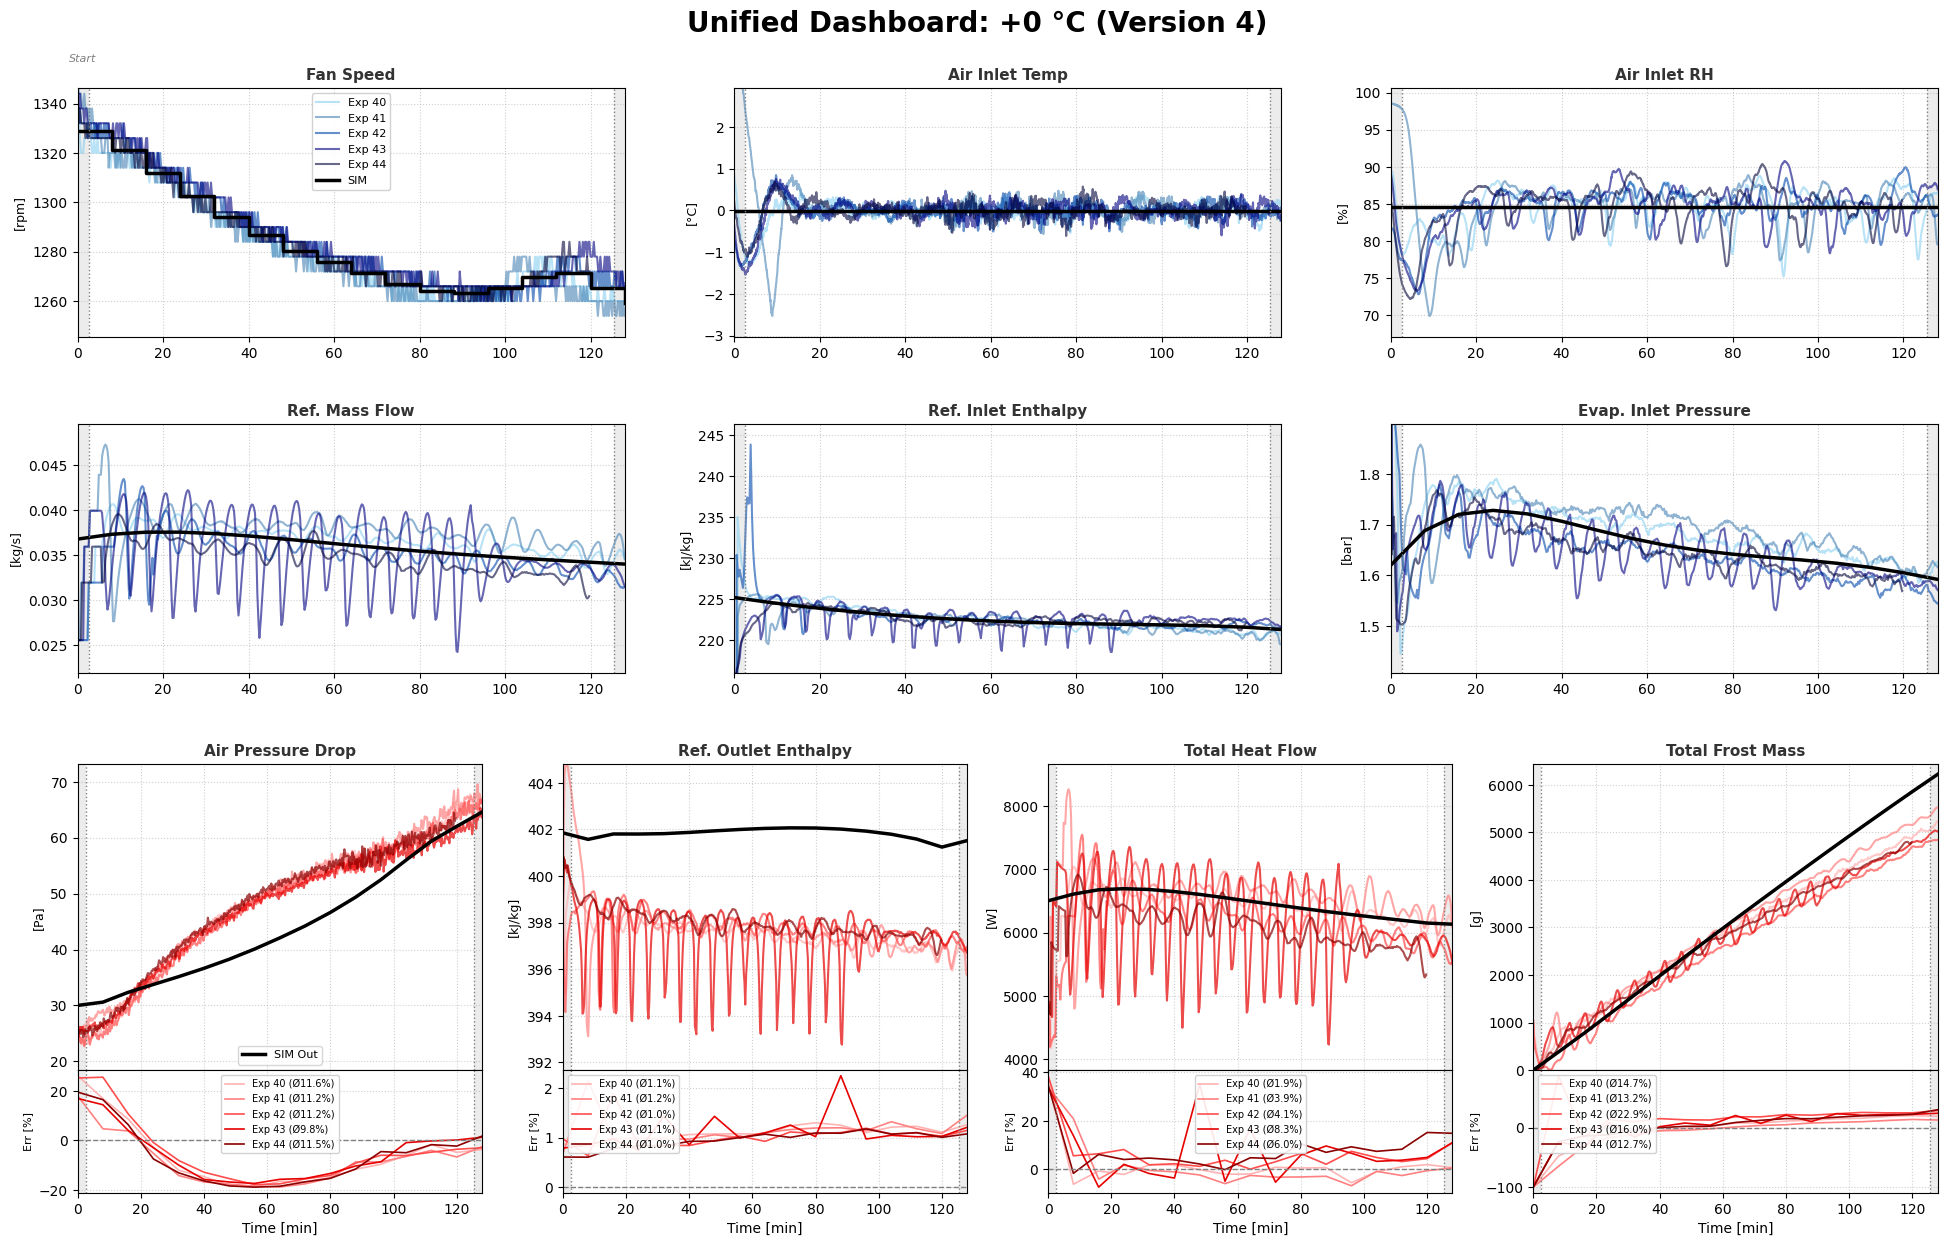

C:\Users\mbc-nba\AppData\Local\Temp\ipykernel_13528\3354423590.py:129: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best', framealpha=0.8)


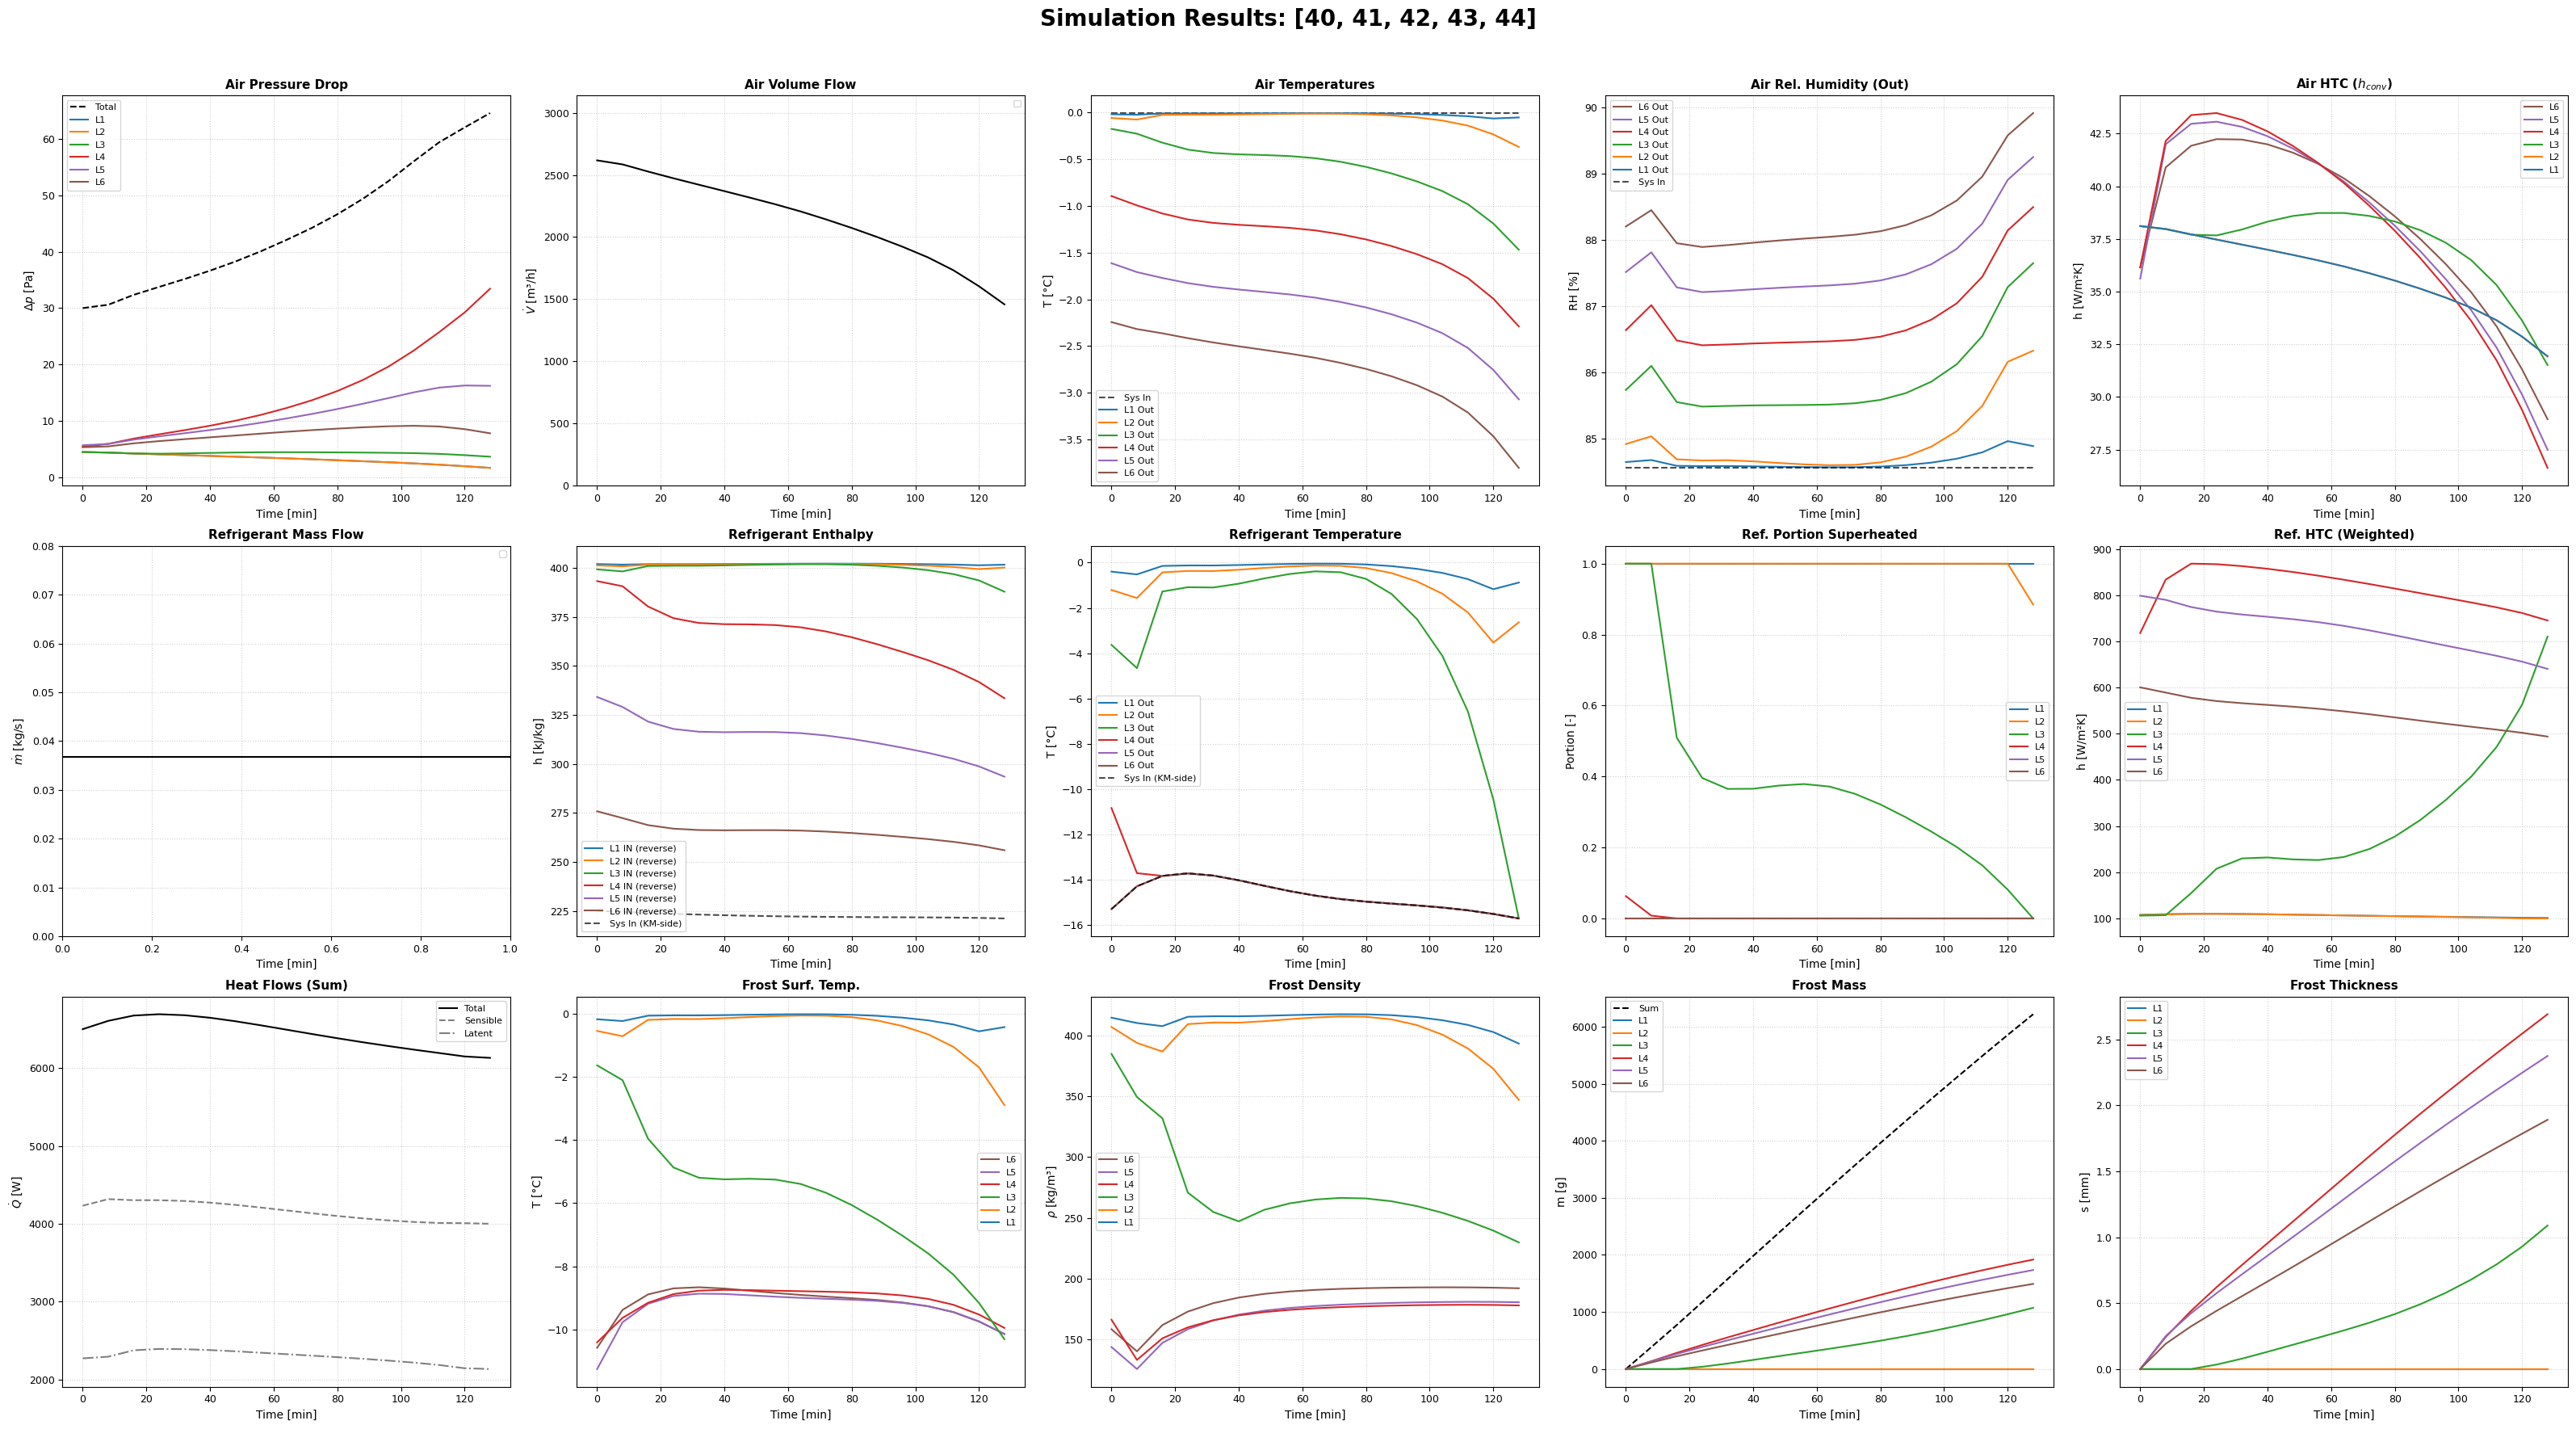

-> Success: Simulation complete for +0 °C (Version 4).

Processing Group: -7 °C
IDs: [27, 28, 29, 30]
--- Aggregating Data for Experiments: [27, 28, 29, 30] ---
--- Simulation of Experiment Combined_4_Exps ---
  Duration      : 240.05 min



--- Initializing Model ---
Model initialized with fluid: R134a


D:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\fan_system_model.py:198: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(




--- Starting Simulation ---


Sim Combined_4_Exps: 100%|██████████| 30/30 [00:56<00:00,  1.89s/it]


--- Processing 4 Experiments ---


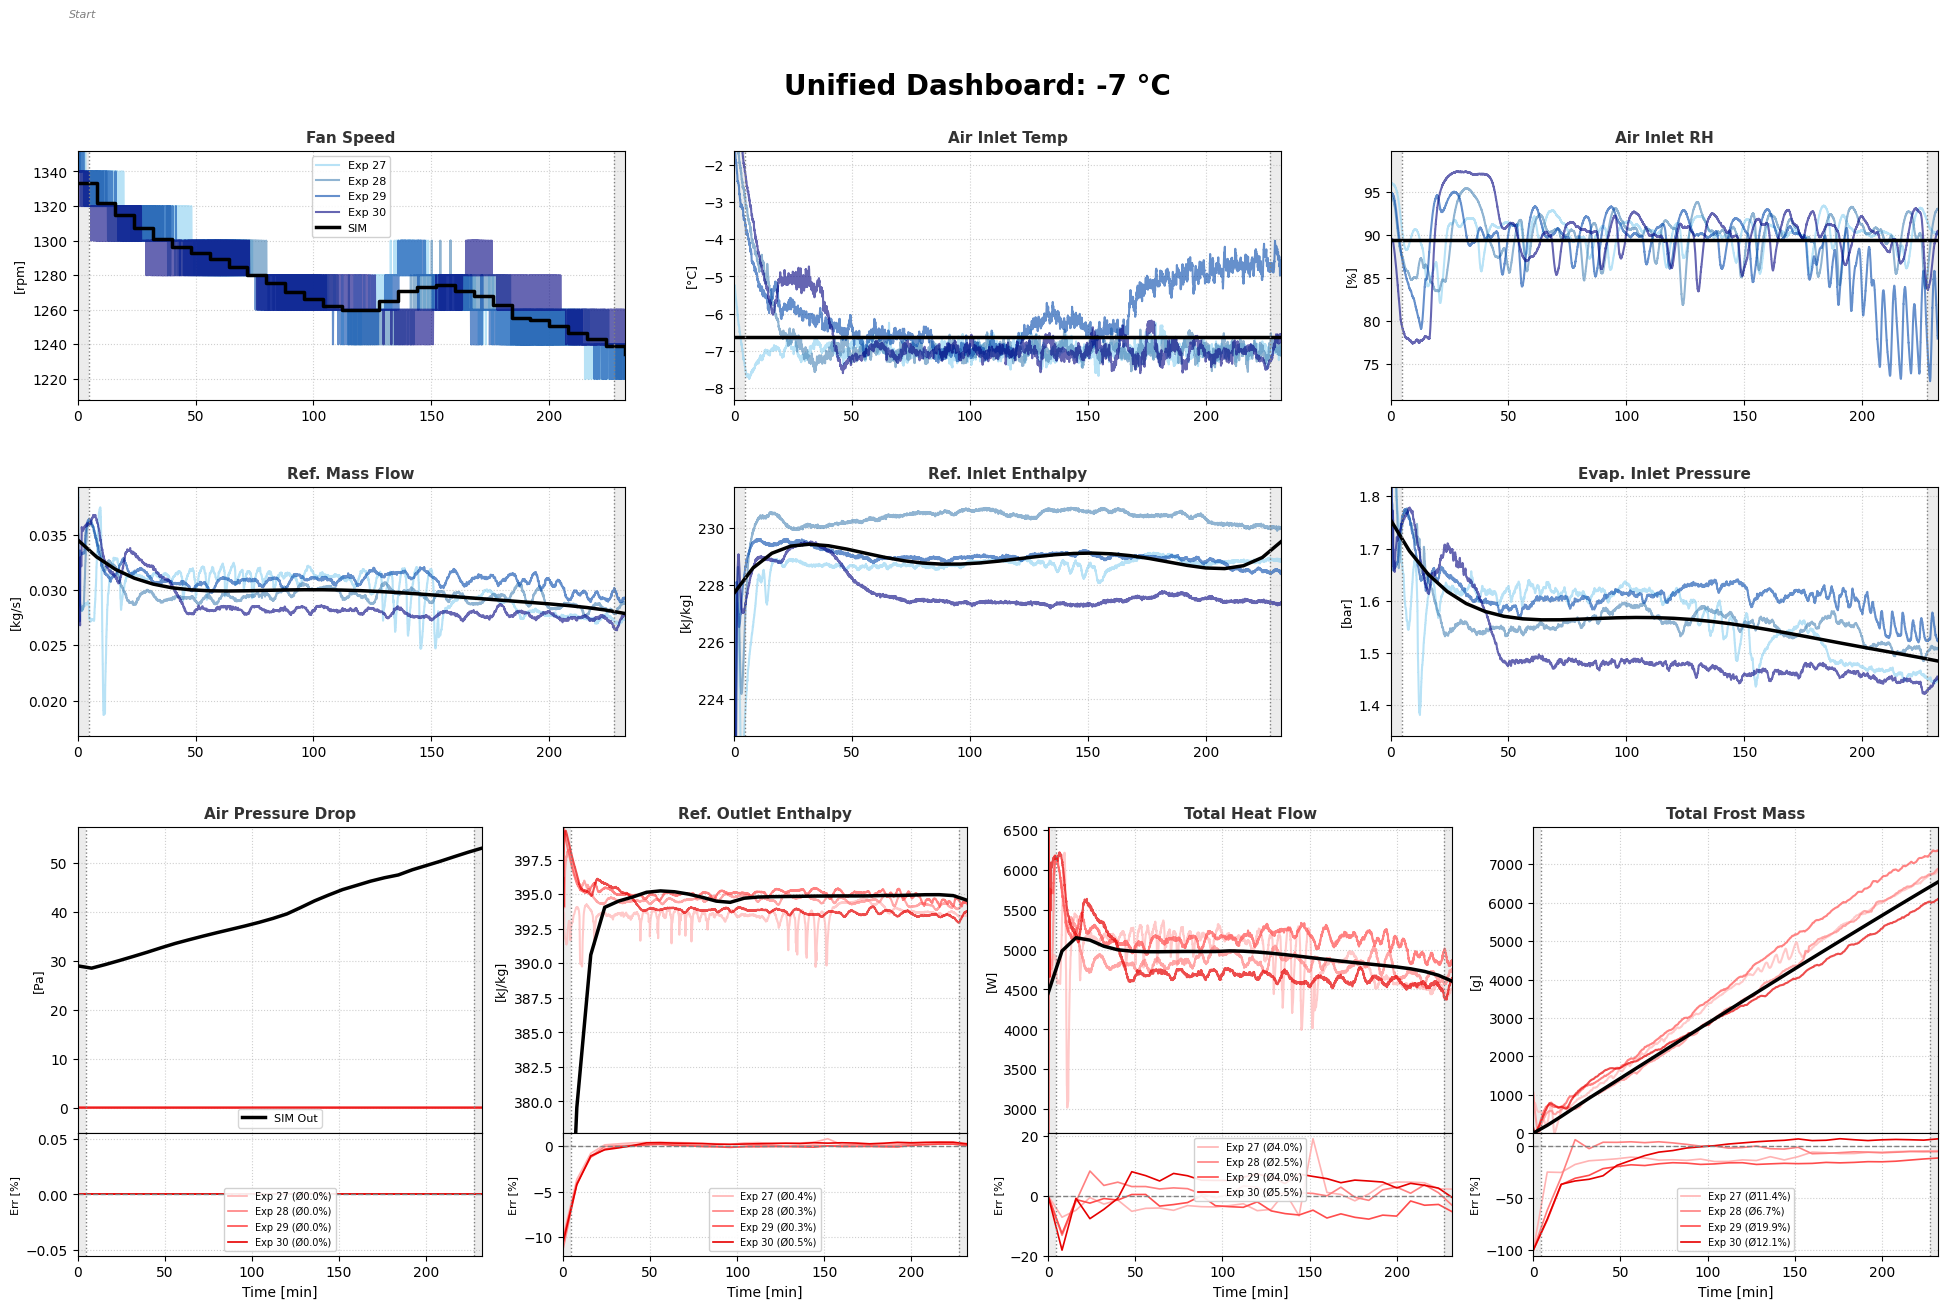

C:\Users\mbc-nba\AppData\Local\Temp\ipykernel_13528\3354423590.py:129: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best', framealpha=0.8)


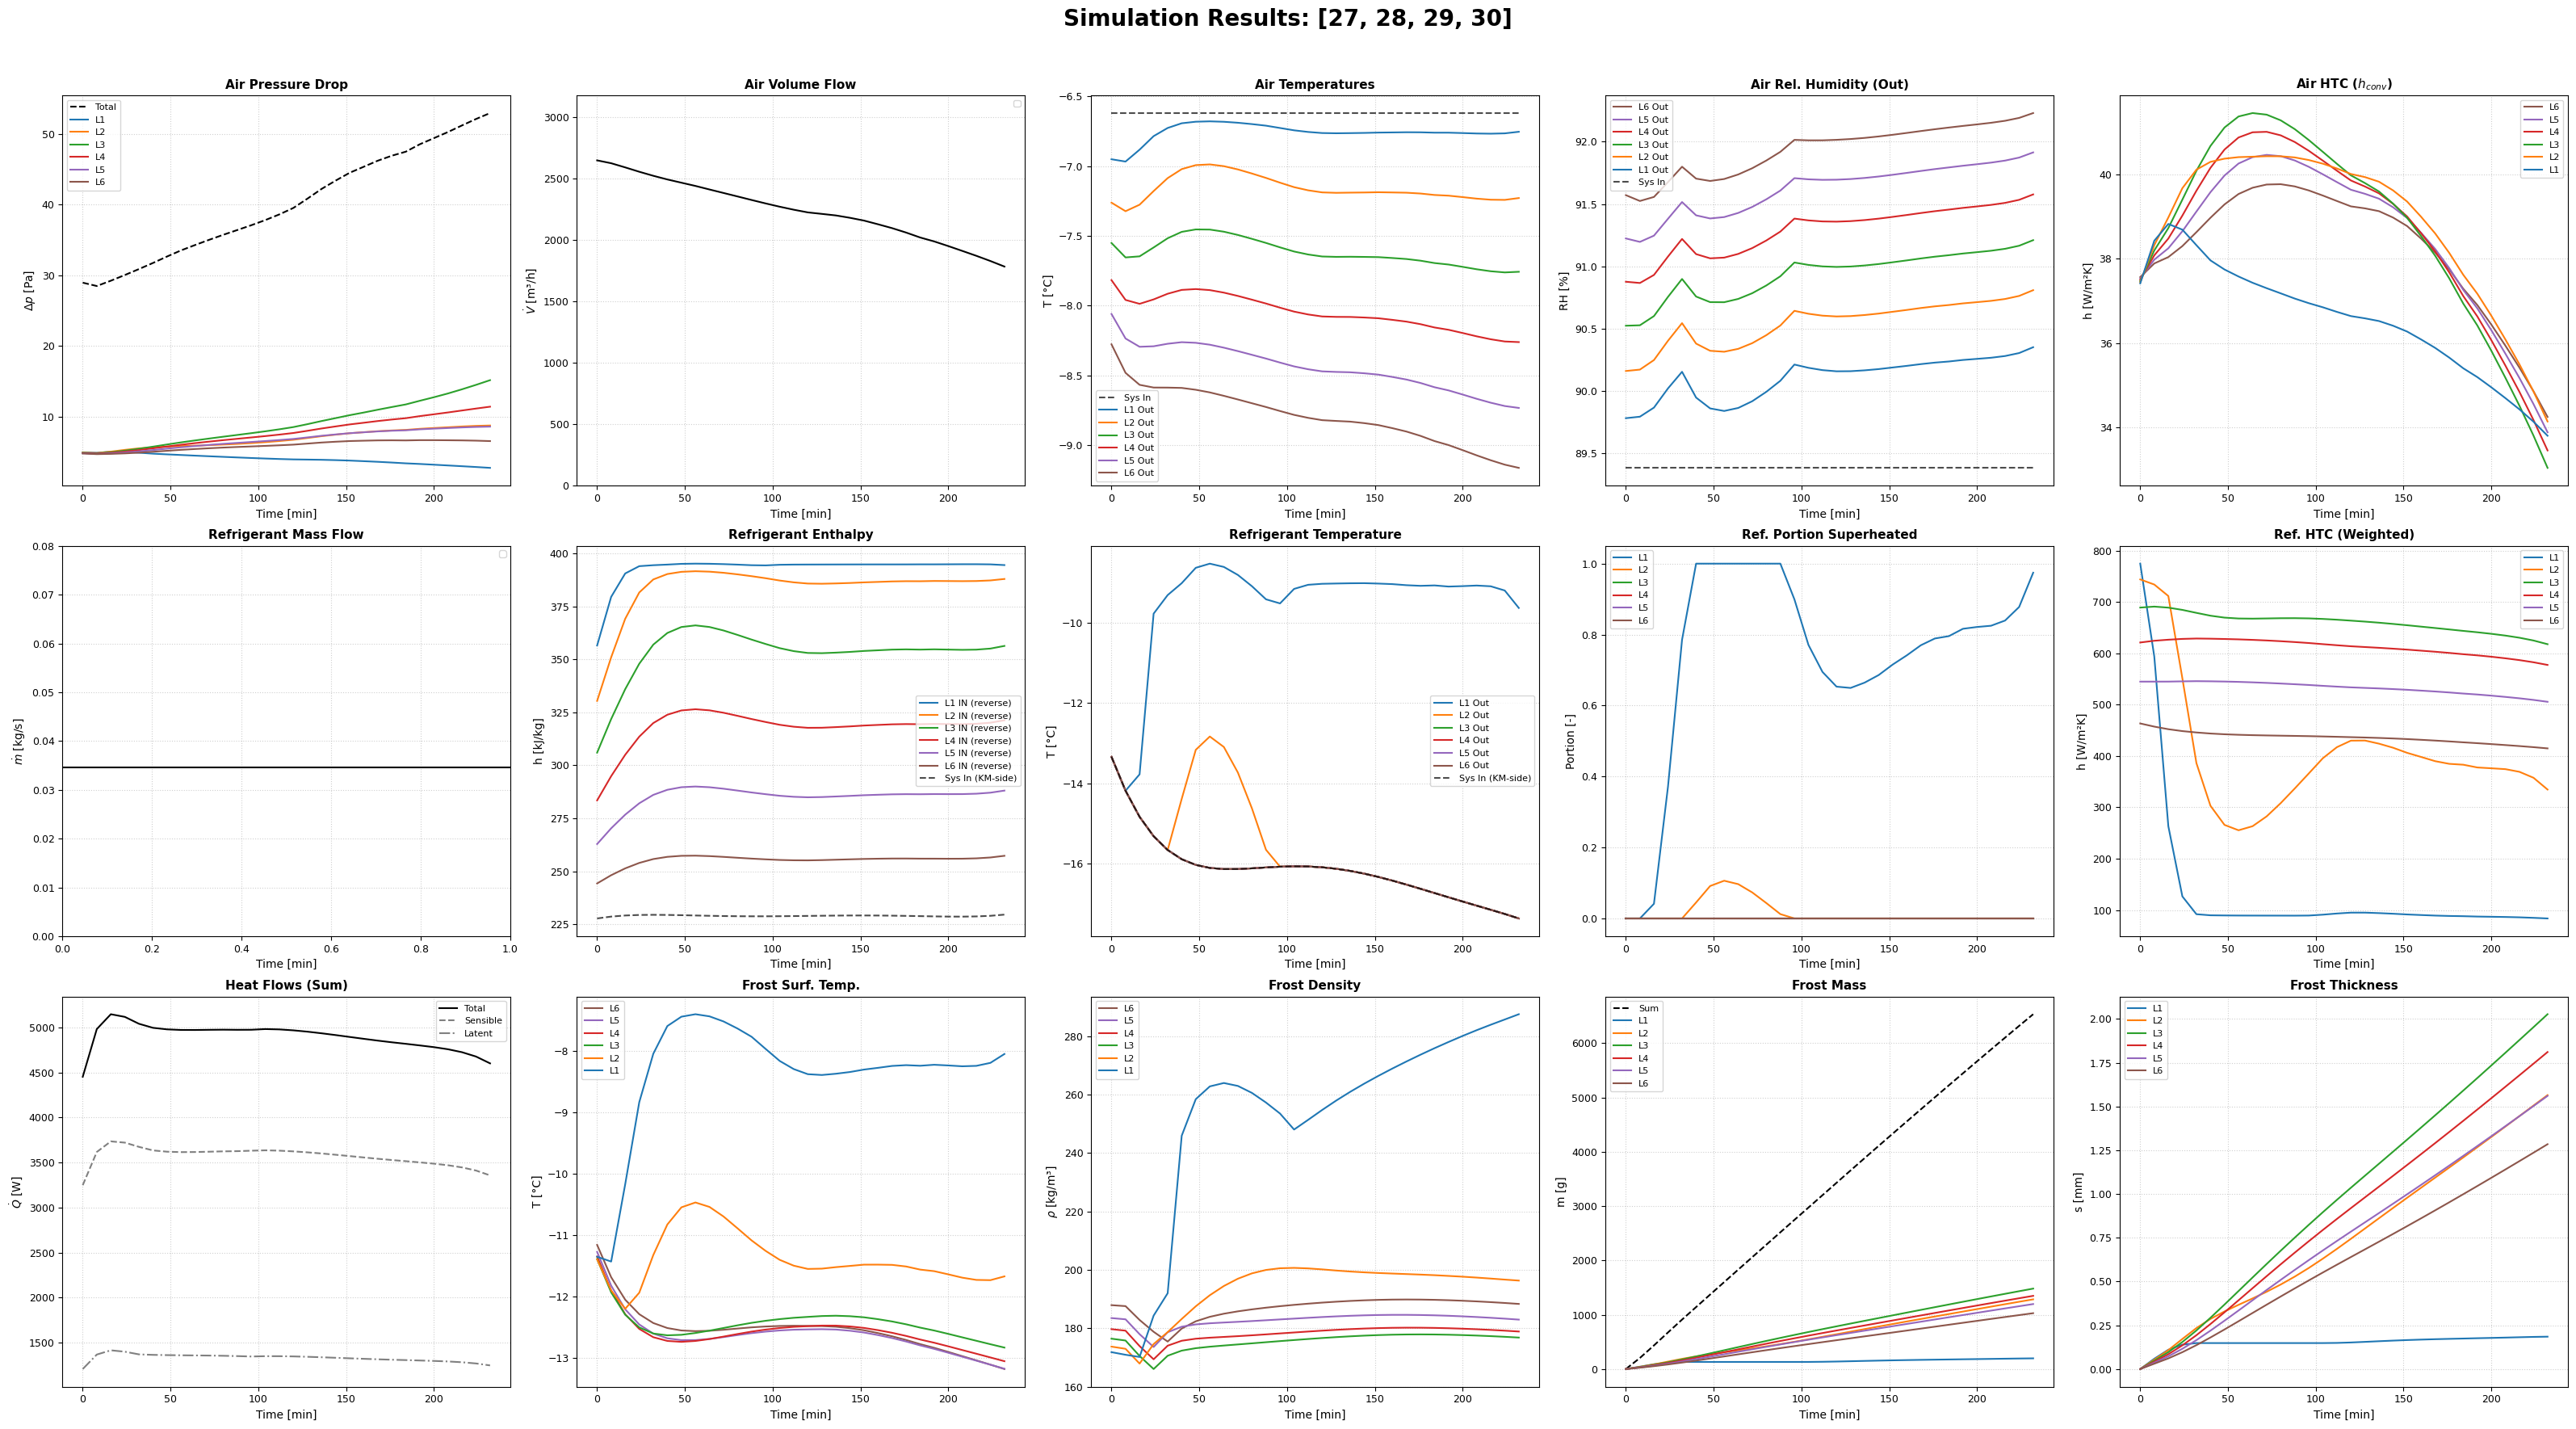

-> Success: Simulation complete for -7 °C.

Processing Group: -12 °C
IDs: [13, 18, 26]
--- Aggregating Data for Experiments: [13, 18, 26] ---
--- Simulation of Experiment Combined_3_Exps ---
  Duration      : 516.62 min



--- Initializing Model ---
Model initialized with fluid: R134a


D:\mbc_nba\vclibpy\frost_evaporator_nba\frost_evaporator\fan_system_model.py:198: UserWarning: [Wang Correlation Validity] Transverse Pitch (Pt) value 50.00 is outside the valid range [17.7 - 31.75]. Results may be inaccurate.
  warnings.warn(




--- Starting Simulation ---


Sim Combined_3_Exps: 100%|██████████| 64/64 [01:28<00:00,  1.39s/it]


--- Processing 3 Experiments ---


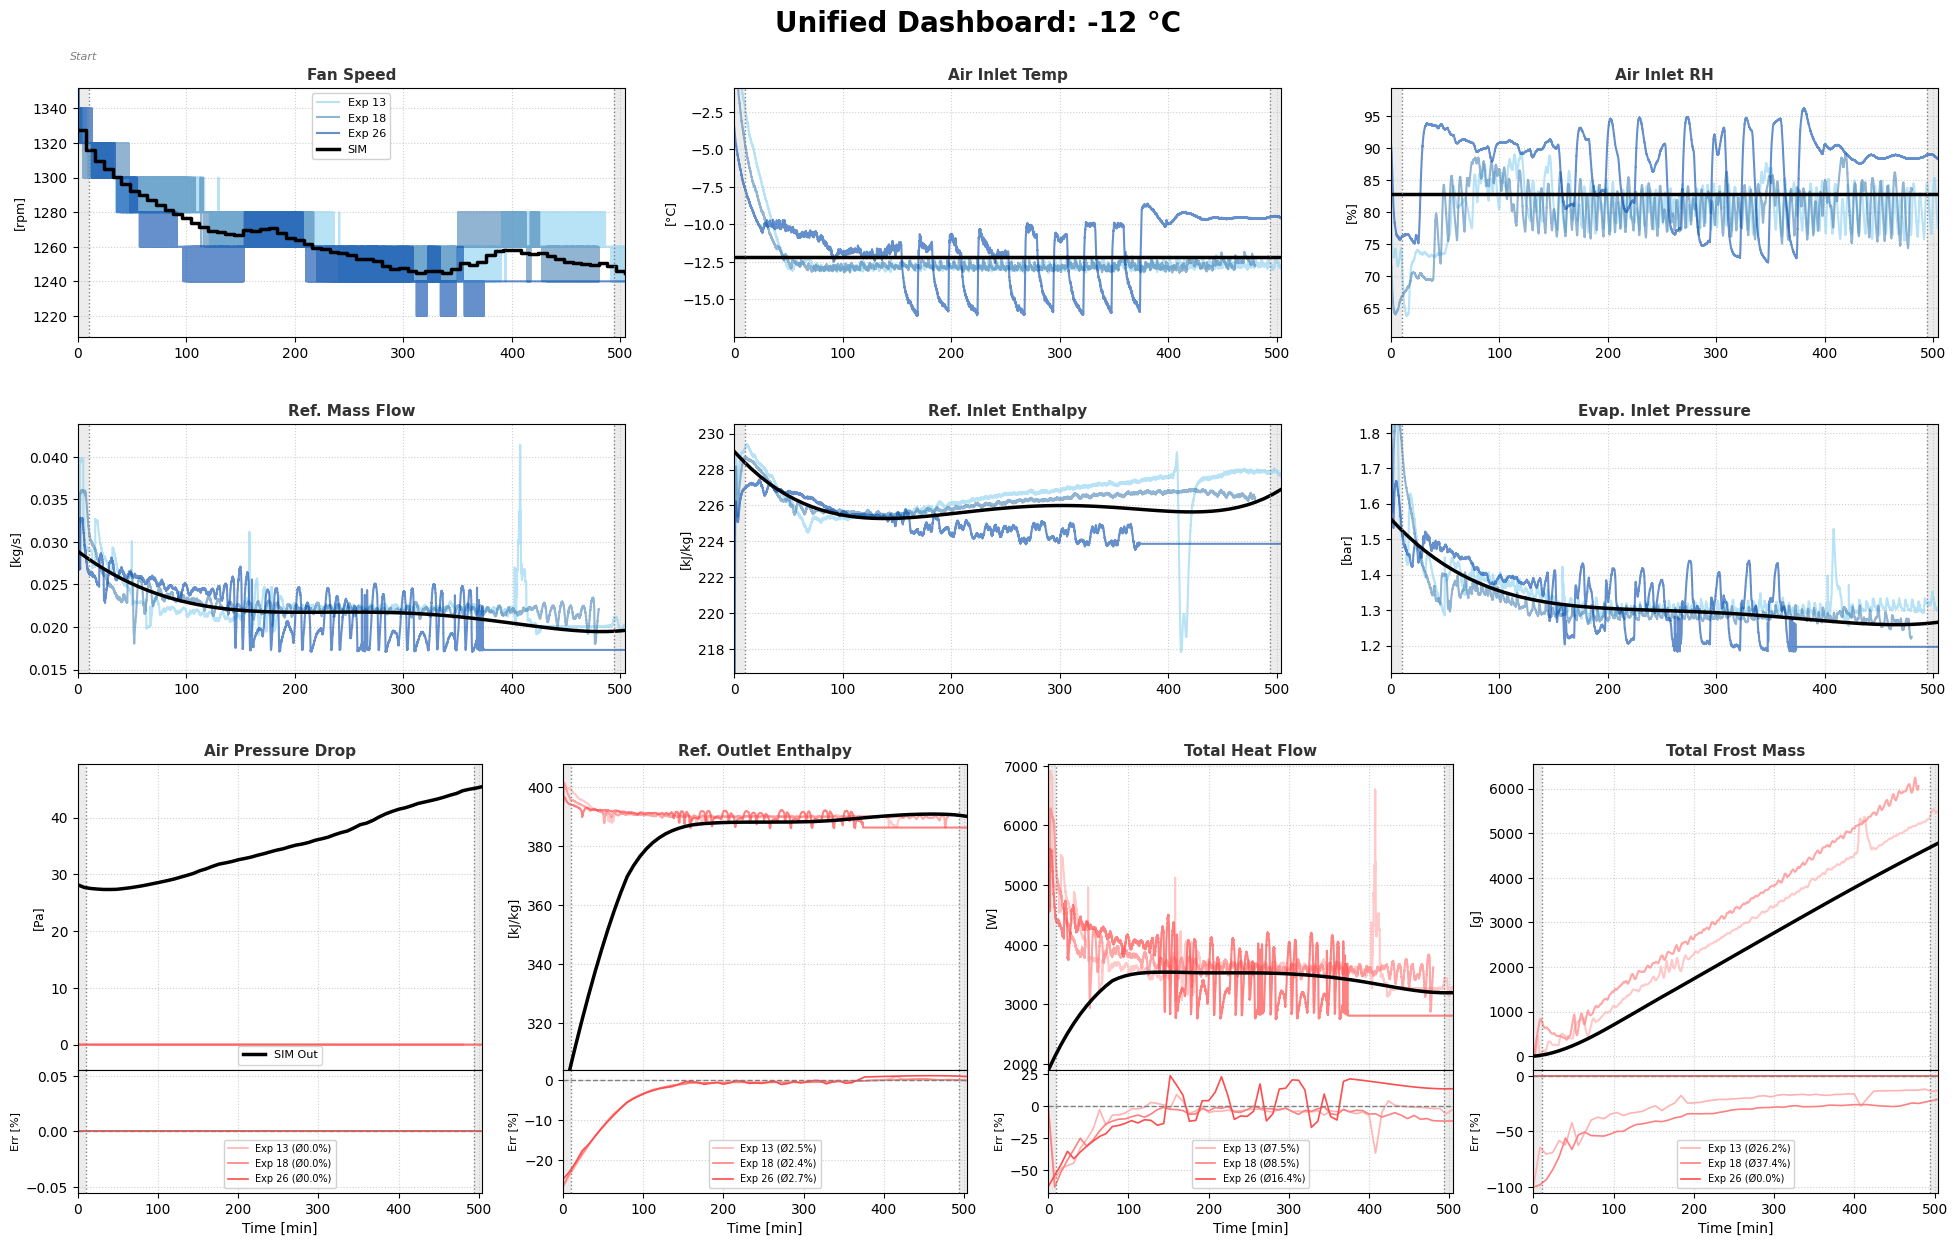

C:\Users\mbc-nba\AppData\Local\Temp\ipykernel_13528\3354423590.py:129: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best', framealpha=0.8)


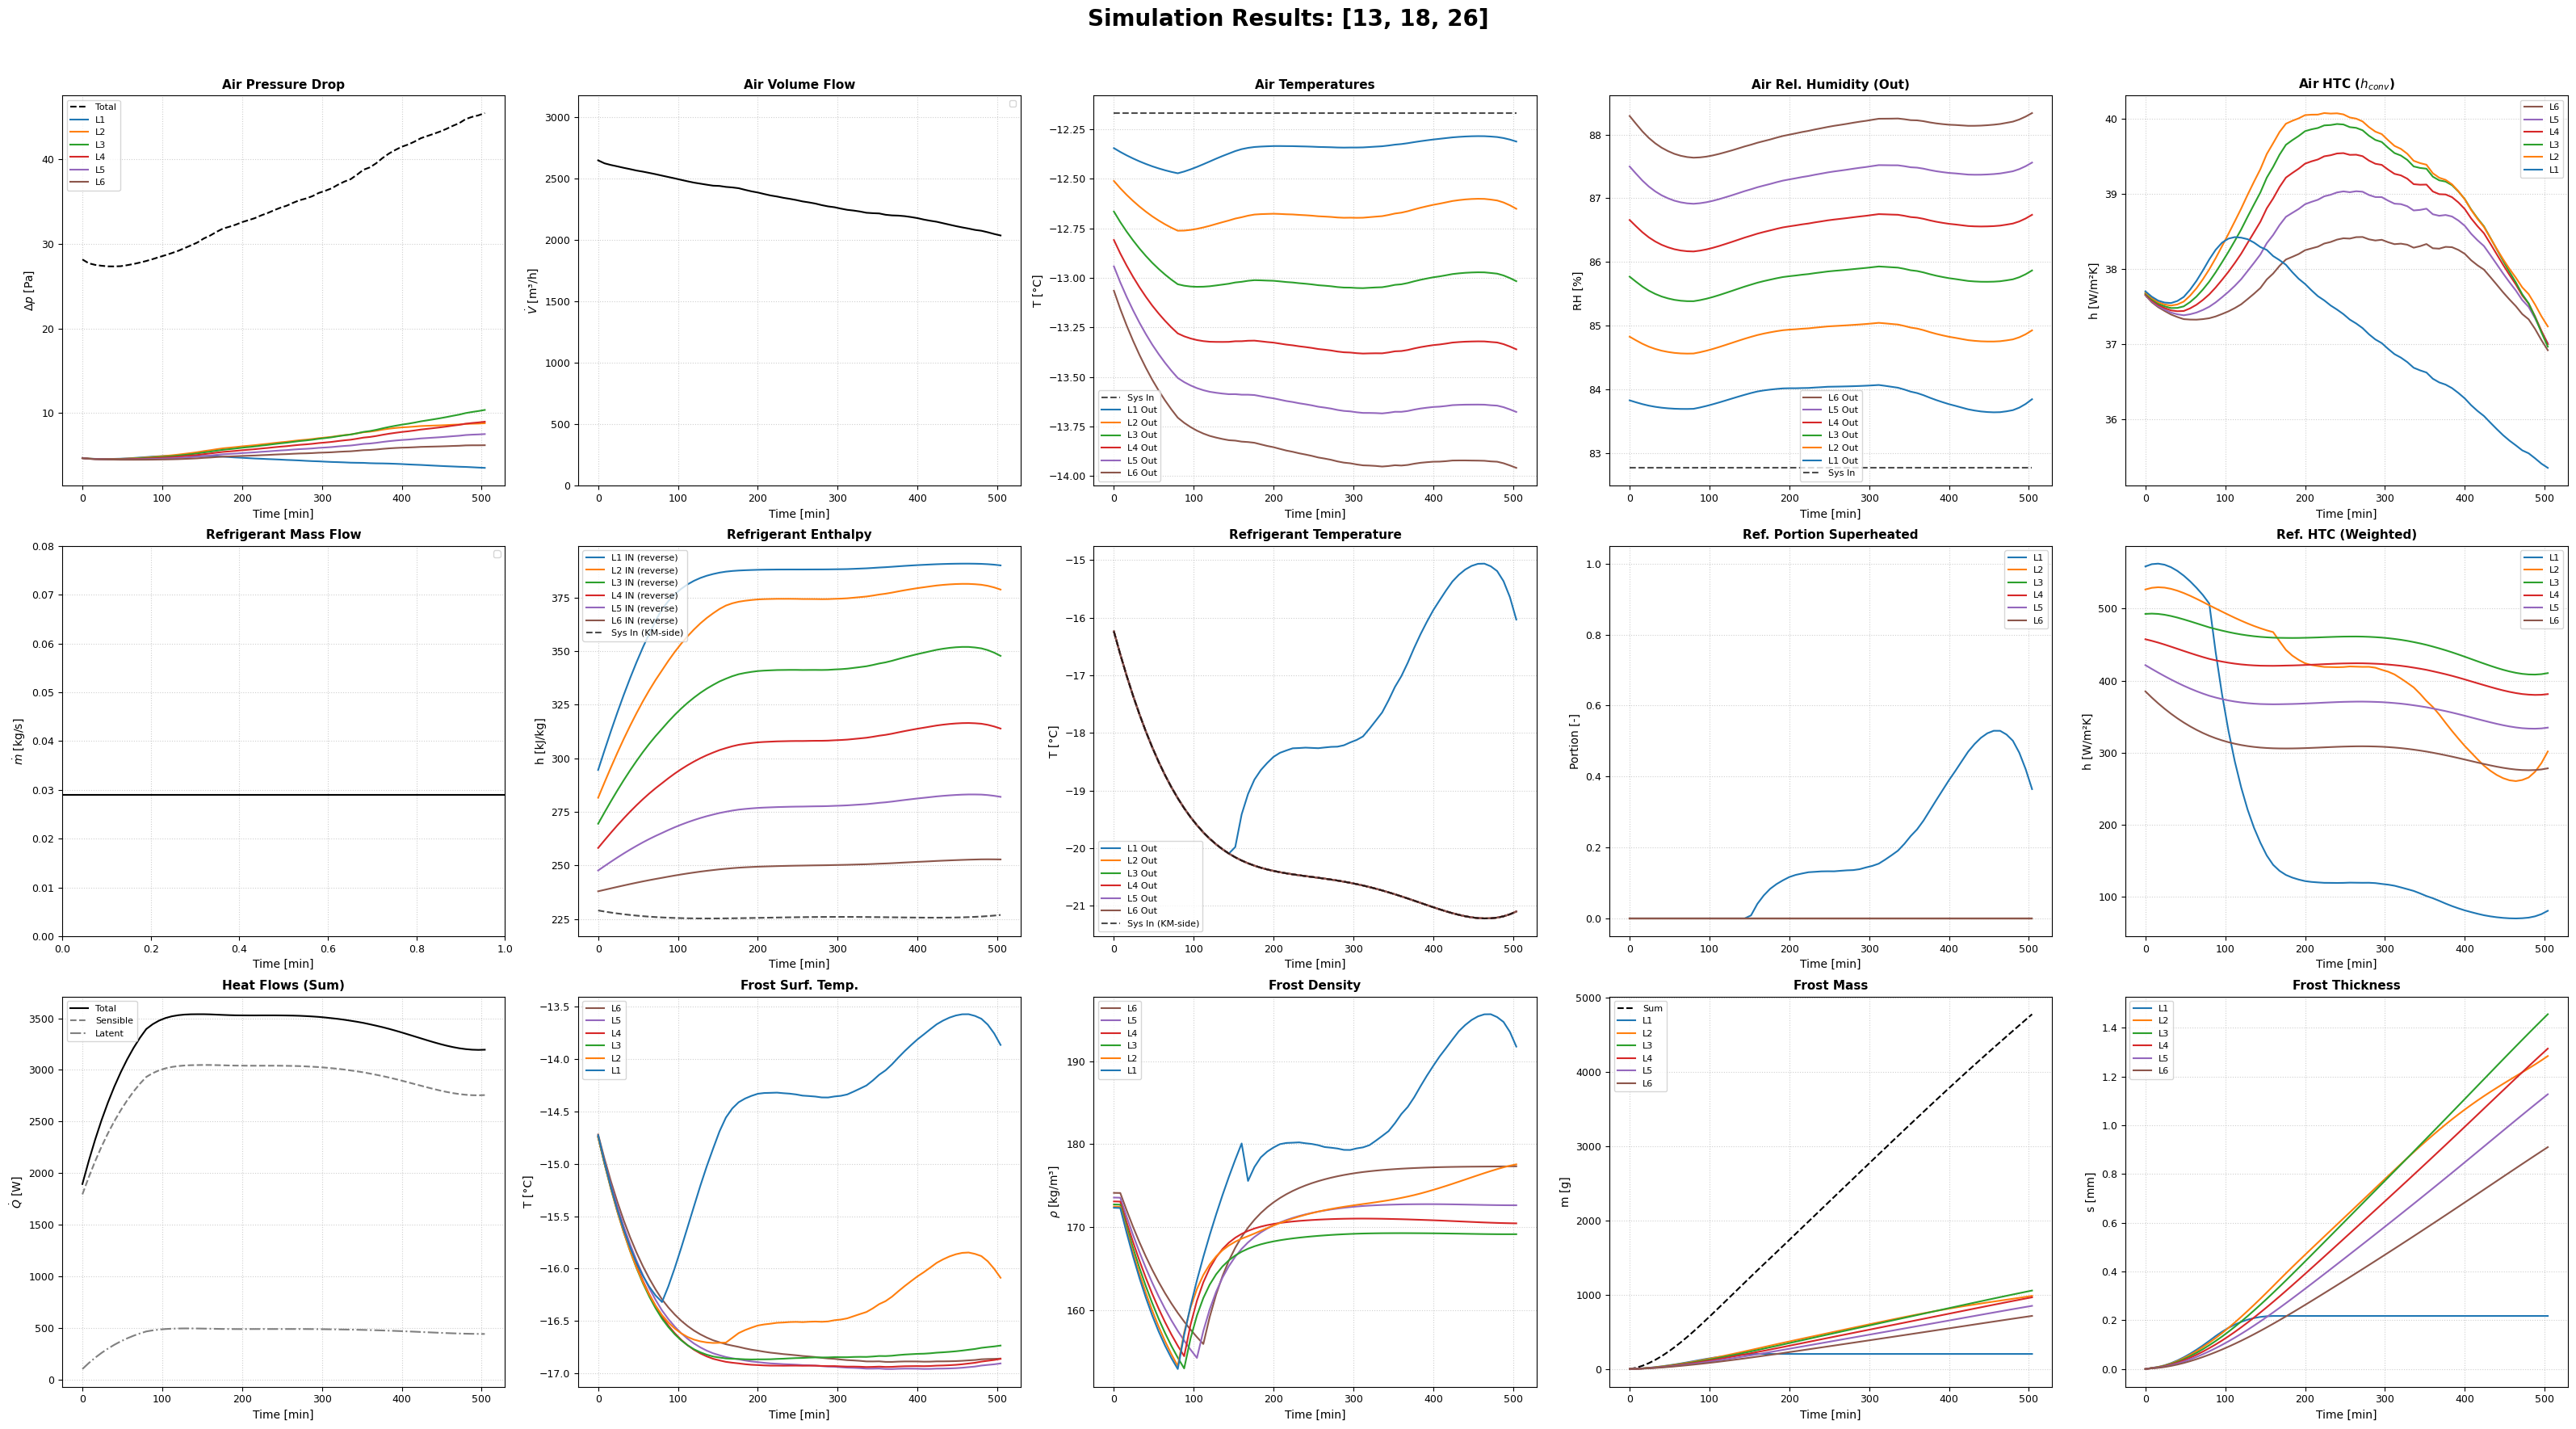

-> Success: Simulation complete for -12 °C.

All experiment groups processed.


In [9]:
from pathlib import Path

# --- MAIN ---

# 1. Define the group of experiments to combine (Label : List of IDs)
experiment_groups = {
    # "tets": [40],

    # "+3 °C":              [52, 53, 55, 56, 67],

    # "+0 °C (Version 1)":  [3, 4, 5, 7, 8],
    # "+0 °C (Version 2)":  [9, 10, 11, 16, 20],
    # "+0 °C (Version 3)":  [20, 22, 23, 25, 36],
    "+0 °C (Version 4)":  [40, 41, 42, 43, 44],
    # "+0 °C (Version 5)":  [45, 46, 47, 48, 49],

    "-7 °C":              [27, 28, 29, 30],
    
    "-12 °C":             [13, 18, 26]
}

cutoff_pct = 0.02
PATH_EXP = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")

# 2. Iterate through each group
for group_name, experiment_ids in experiment_groups.items():
    
    print(f"\n{'='*40}")
    print(f"Processing Group: {group_name}")
    print(f"IDs: {experiment_ids}")
    print(f"{'='*40}")

    try:
        # A. Aggregate Data & Create Trends
        combined_exp_inputs = analyze_combined_experiments(experiment_ids, PATH_EXP, cutoff_pct, time_step=params.time_step)
        
        # B. Run ONE Simulation based on the combined trends
        states_history, inputs_history = run_simulation_case(combined_exp_inputs, params)

        # C. Plot 
        # Note: Ensure your plot function handles unique filenames based on IDs to avoid overwriting!
        plot_all_comparison_multi(states_history, inputs_history, params, experiment_ids, PATH_EXP, cutoff_pct, save_fig=False, group_name=group_name)
        create_detailed_plot(states_history, inputs_history, params, experiment_ids)
        # plot_roughness_analysis(states_history, params, experiment_ids[0])
        # visualize_frost_distribution(states_history, params, time_step_index=-1)
        # plot_all_debug(states_history, inputs_history, params, exp_id)
        # get_total_relative_error_multi(states_history, params, experiment_ids, PATH_EXP, cutoff_pct)

        print(f"-> Success: Simulation complete for {group_name}.")

    except Exception as e:
        import traceback
        print(f"!!! CRITICAL FAILURE in Group {group_name} !!!")
        print(f"Error Message: {e}")
        traceback.print_exc()
        print("-> Skipping to next group...")

print(f"\nAll experiment groups processed.")

In [10]:

# # combined_exp_inputs = analyze_combined_experiments(experiment_ids, PATH_EXP, cutoff_pct)

# # plot_input_comparison(states_history, inputs_history, params, experiment_ids, PATH_EXP, cutoff_pct, save_fig=False)


# target_data = get_group_average_data(experiment_ids, PATH_EXP, cutoff_pct)

# sim_res = {
#     'dp': np.array([sum(s.air.pressure_drop for s in step) for step in states_history]),
#     'Q': np.array([sum(s.hmt.Q_dot_total for s in step) * REGISTER_AMOUNT for step in states_history]),
#     'm_frost': np.array([sum(s.frost.mass for s in step) * 1000.0 * REGISTER_AMOUNT for step in states_history])
# }

# calculate_loss(sim_res, target_data)


<!-- ### Run Mutliple Simulations -->

### Optimization

In [11]:
# import optuna
# import numpy as np
# import pandas as pd
# import os
# from pathlib import Path

# # =========================================================================
# # 1. KONFIGURATION
# # =========================================================================
# OPTIMIZATION_SETS = {
#     "Group_Plus0":   [40, 41, 42, 43, 44],
#     "Group_Minus7":  [27, 28, 29, 30],
#     "Group_Minus12": [13, 18, 26]
# }
# CUTOFF_PCT = 0.02
# PATH_EXP = Path(r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export")
# PARAM_RANGE = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]

# # =========================================================================
# # 2. ROBUSTE HILFSFUNKTIONEN
# # =========================================================================

# def to_numpy(data):
#     """Konvertiert Pandas Series/DataFrames sicher in Numpy, falls nötig."""
#     if hasattr(data, "values"):
#         return data.values
#     return np.array(data)

# def get_group_average_data(experiment_ids, path_exp, cutoff_pct):
#     """
#     Lädt Experimente und bildet Durchschnittswerte. 
#     Behandelt 'all zero' Spalten und Attribut-Fehler.
#     """
#     group_results = {'dp': [], 'Q': [], 'm_frost': []}
    
#     for exp_id in experiment_ids:
#         try:
#             f_data = path_exp / f"{exp_id}_data.csv"
#             f_kk = path_exp / f"{exp_id}_data_KK.csv"
            
#             if not f_data.exists() or not f_kk.exists():
#                 continue

#             df = pd.read_csv(f_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
#             df_kk = pd.read_csv(f_kk, sep=';', decimal='.', low_memory=False)

#             # Filterung (Modus 1 = Aktive Simulation)
#             col_modus = 'modus_val' if 'modus_val' in df.columns else 'modus'
#             if col_modus in df.columns:
#                 mask = df[col_modus] == 1
#                 df = df[mask]
#                 df_kk = df_kk.iloc[df.index] # Synchronisieren

#             if df.empty:
#                 continue

#             # --- EXTRAKTION MIT FEHLERHANDLING ---
#             # Druckverlust
#             dp = to_numpy(df['Delta_P_VD']) if 'Delta_P_VD' in df.columns else np.zeros(len(df))
            
#             # Wärmestrom Q = m_dot * (h_out - h_in)
#             m_ref = to_numpy(df['MSS_rMassenstrom']) / 1000.0
#             h_out = to_numpy(df['VD_h_out'])
#             h_in_col = 'VD_h_in_korr' if 'VD_h_in_korr' in df.columns else 'VD_isenthalp_h_in'
#             h_in = to_numpy(df[h_in_col])
#             Q = m_ref * (h_out - h_in) * 1000.0

#             # Frostmasse
#             col_mass = 'WAAGEN_Waage1_Masse_smooth' if 'WAAGEN_Waage1_Masse_smooth' in df.columns else 'WAAGEN_Waage2_Masse'
#             if col_mass in df.columns:
#                 m_raw = to_numpy(df[col_mass])
#                 m_frost = (m_raw - np.nanmin(m_raw)) * 1000.0
#             else:
#                 m_frost = np.zeros(len(df))

#             group_results['dp'].append(dp)
#             group_results['Q'].append(Q)
#             group_results['m_frost'].append(m_frost)

#         except Exception as e:
#             print(f"Fehler bei ID {exp_id}: {e}")

#     # Aggregation: Wir mitteln die Verläufe
#     final_avg = {}
#     for key, lists in group_results.items():
#         if lists:
#             # Da Zeitreihen unterschiedliche Längen haben können, 
#             # nehmen wir hier den Median der Endwerte oder interpolieren auf eine Standardlänge
#             # Vereinfachung für die Optimierung:
#             max_len = max(len(l) for l in lists)
#             padded_lists = [np.pad(l, (0, max_len - len(l)), 'edge') for l in lists]
#             final_avg[key] = np.mean(padded_lists, axis=0)
#         else:
#             final_avg[key] = None
            
#     return final_avg

# def calculate_loss(sim_res, target_data):
#     """Berechnet Fehler zwischen Simulation und gemitteltem Experiment."""
#     total_err = 0
#     valid_metrics = 0
    
#     for key in ['dp', 'Q', 'm_frost']:
#         if target_data[key] is not None:
#             # Interpolation der Simulation auf die Länge der Experimental-Daten
#             y_sim = sim_res[key]
#             y_exp = target_data[key]
            
#             if len(y_sim) != len(y_exp):
#                 y_sim = np.interp(np.linspace(0, 1, len(y_exp)), np.linspace(0, 1, len(y_sim)), y_sim)

#             # Cutoff anwenden
#             start = int(len(y_exp) * CUTOFF_PCT)
#             end = int(len(y_exp) * (1 - CUTOFF_PCT))
            
#             y_sim_c = y_sim[start:end]
#             y_exp_c = y_exp[start:end]
            
#             # RMSE oder MAPE (MAPE hier robuster für unterschiedliche Skalen)
#             denom = np.abs(np.mean(y_exp_c))
#             if denom < 1e-3: denom = 1.0 # Schutz gegen div/0
            
#             err = np.sqrt(np.mean((y_sim_c - y_exp_c)**2)) / denom
#             total_err += err
#             valid_metrics += 1
            
#     return total_err / valid_metrics if valid_metrics > 0 else 1e6

# # =========================================================================
# # 3. OPTUNA TRIAL
# # =========================================================================

# def objective(trial):
#     # Parameter vorschlagen
#     params.correction_factor_h_conv_air = trial.suggest_categorical("h_conv", PARAM_RANGE)
#     params.correction_factor_surface_density = trial.suggest_categorical("surf_dens", PARAM_RANGE)
#     params.correction_factor_betta_air = trial.suggest_categorical("betta", PARAM_RANGE)
#     params.correction_factor_k_frost = trial.suggest_categorical("k_frost", PARAM_RANGE)

#     group_losses = []
    
#     for group_name, ids in OPTIMIZATION_SETS.items():
#         # 1. Aggregierte Eingangsdaten für die Simulation
#         combined_inputs = analyze_combined_experiments(ids, PATH_EXP, CUTOFF_PCT, time_step=params.time_step)
        
#         # 2. Simulation
#         states, inputs = run_simulation_case(combined_inputs, params)
        
#         # 3. Sim-Ergebnisse extrahieren
#         sim_res = {
#             'dp': np.array([sum(s.air.pressure_drop for s in step) for step in states]),
#             'Q': np.array([sum(s.hmt.Q_dot_total for s in step) * REGISTER_AMOUNT for step in states]),
#             'm_frost': np.array([sum(s.frost.mass for s in step) * 1000.0 * REGISTER_AMOUNT for step in states])
#         }
        
#         # 4. Vergleichsdaten laden
#         target_data = get_group_average_data(ids, PATH_EXP, CUTOFF_PCT)
        
#         # 5. Loss berechnen
#         group_losses.append(calculate_loss(sim_res, target_data))
        
#     return np.sum(group_losses)

# # =========================================================================
# # 4. START
# # =========================================================================
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=500)

# print("Beste Parameter:", study.best_params)